## This Notebook trains a Neural Network for Galaxy-Matter-Powerspektra Predictions

In [1]:
import g3lhalo
import pyccl as ccl
import matplotlib.pyplot as plt
import numpy as np
import random
from pyDOE import lhs
import tensorflow as tf
import matplotlib.pyplot as plt
import json
import os
from datetime import datetime
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.activations import gelu
from tensorflow.keras.losses import MeanSquaredError
import tensorflow_addons as tfa
import optuna
from tensorflow.keras.layers import LeakyReLU, ELU
import ast

# Für spezielle Aktivierungen wie Swish, GELU
try:
    from tensorflow.keras.activations import swish, gelu
except ImportError:
    # Alternative falls alte TensorFlow-Version
    def swish(x): return x * tf.nn.sigmoid(x)
    def gelu(x): return 0.5 * x * (1.0 + tf.tanh(tf.sqrt(2.0 / tf.constant(np.pi)) * (x + 0.044715 * tf.pow(x, 3))))

# Für AdamW und RAdam Optimizer:
try:
    from tensorflow_addons.optimizers import AdamW, RectifiedAdam
except ImportError:
    # Falls nicht installiert:
    # pip install tensorflow-addons
    print("Installiere tensorflow-addons mit: pip install tensorflow-addons")

2025-08-18 16:04:15.279219: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-18 16:04:15.282756: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-08-18 16:04:15.340967: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-08-18 16:04:15.342603: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-08-18 16:04:24.720719: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT

In [2]:
#%pip install tensorflow
#%pip install pyDOE
#%pip install pandas
#%pip install seaborn
#%pip install tensorflow-addons
#%pip install filelock
#%pip install pyccl

In [3]:
# checking that we are using a GPU
device = 'gpu:0' if tf.test.is_gpu_available() else 'cpu'
print('using', device, 'device \n')

Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.
using cpu device 



## Read in generated Targets

In [ ]:
# 1. Speicherort und Dateiname

data_dir = "../Data/"
dataset = "1000000_2025-06-11_05-16-31"
data_fn = f"{data_dir}GeneratedData_{dataset}.json"

# 2. Relevante Keys für Galaxy-Matter

powerspectrum_mode = "ss"

target_keys = [f'Pk_{powerspectrum_mode}_1h', f'Pk_{powerspectrum_mode}_2h', f'Pk_{powerspectrum_mode}']
lin_keys = ['Pk_lin']


# 3. Daten einlesen und filtern

clean_samples = []
kept_indices = []
with open(data_fn, "r") as json_file:
    data_samples = json.load(json_file)
    for i, sample in enumerate(data_samples):
        if all(np.all(np.array(sample[key]) >= 0) for key in target_keys):
            clean_samples.append(sample)
            kept_indices.append(i)

print(f"Anzahl der verbleibenden (bereinigten) Samples: {len(clean_samples)}")


# Create numpy arrays for each of the Pk_* columns
targets_array = {
    key: np.array([sample[key] for sample in clean_samples])
    for key in target_keys
}


# Logarithmic transformation of the data
def log_transform(targets_array):
    return {key: np.log(data) for key, data in targets_array.items()}

#epsilon = 1e-8
#for key in targets_array:
    #targets_array[key] = np.where(targets_array[key] <= 0, epsilon, targets_array[key])

# Calculate logarithms of the data
log_transformed_data = log_transform(targets_array)

num_samples = len(clean_samples)
indices = np.arange(num_samples)

np.random.seed(9721)
tf.random.set_seed(9721)
np.random.shuffle(indices)

training_indices = indices[:50000]
validation_indices = indices[50000:60000]
testing_indices = indices[60000:]

N_train = len(training_indices)
N_val = len(validation_indices)
N_test = len(testing_indices)

print(f"Training: {len(training_indices)}")
print(f"Validation: {len(validation_indices)}")
print(f"Test: {len(testing_indices)}")

# 8. Hilfsfunktion zum Splitten
def split_data(array_dict, split_indices):
    return np.array([data[split_indices] for data in array_dict.values()])

# 9. Targets und Modes für Splits
training_targets = {
    'modes': split_data(targets_array, training_indices),
    'targets': split_data(log_transformed_data, training_indices)
}

validation_targets = {
    'modes': split_data(targets_array, validation_indices),
    'targets': split_data(log_transformed_data, validation_indices)
}

testing_targets = {
    'modes': split_data(targets_array, testing_indices),
    'targets': split_data(log_transformed_data, testing_indices)
}

Anzahl der verbleibenden (bereinigten) Samples: 1000000
Training: 50000
Validation: 10000
Test: 940000


In [6]:
print('number of training targets:', len(training_targets['modes'][:][0]), '. Should be', len(training_indices))
print('number of validation targets:', len(validation_targets['modes'][:][0]), '. Should be', len(validation_indices))

print('number of test targets:', len(testing_targets['modes'][:][0]), '. Should be', len(testing_indices))


number of training targets: 50000 . Should be 50000
number of validation targets: 10000 . Should be 10000
number of test targets: 940000 . Should be 940000


In [7]:
N_modes=len(training_targets['modes'])
print(f"Shape of training targets: {training_targets['targets'].shape}. Should be ({N_modes}, {len(training_indices)}, 50)")
print(f"Shape of testing targets: {testing_targets['targets'].shape}. Should be ({N_modes}, {len(testing_indices)}, 50)")
print(f"Shape of validation targets: {validation_targets['targets'].shape}. Should be ({N_modes}, {len(validation_indices)}, 50)")

Shape of training targets: (3, 50000, 50). Should be (3, 50000, 50)
Shape of testing targets: (3, 940000, 50). Should be (3, 940000, 50)
Shape of validation targets: (3, 10000, 50). Should be (3, 10000, 50)


## Read in lin

In [8]:
#print('number of training targets:', len(lin_training_targets['modes'][:][0]), '. Should be', N_train)
#print('number of validation targets:', len(lin_validation_targets['modes'][:][0]), '. Should be', N_val)

#print('number of test targets:', len(lin_testing_targets['modes'][:][0]), '. Should be', N_test)

In [9]:
#N_modes=len(lin_training_targets['modes'])
#print(f"Shape of training targets: {lin_training_targets['modes'].shape}. Should be ({N_modes}, {N_train}, 50)")
#print(f"Shape of testing targets: {lin_testing_targets['modes'].shape}. Should be ({N_modes}, {N_test}, 50)")
#print(f"Shape of validation targets: {lin_validation_targets['modes'].shape}. Should be ({N_modes}, {N_val}, 50)")

## Read in related features

In [ ]:
# Parameterdatei einlesen
para_fn = f"{data_dir}Parameter_{dataset}.json"

with open(para_fn, "r") as json_file:
    all_parameter_samples = json.load(json_file)


# Create numpy arrays for each of the parameter columns
feature_keys = ['Om_c', 'Om_b', 'h', 'sigma_8', 'n_s', 'alpha', 'sigma', 'Mth', 'Mprime', 'beta']

# List of arrays for each parameter
feature_array = {key: np.array([sample[key] for sample in samples]) for key in feature_keys}

# Split features into training, validation and test data
training_features = {key: feature[training_indices] for key, feature in feature_array.items()}
validation_features = {key: feature[validation_indices] for key, feature in feature_array.items()}
testing_features = {key: feature[testing_indices] for key, feature in feature_array.items()}

training_features = np.array(list(zip(*training_features.values())))
validation_features = np.array(list(zip(*validation_features.values())))
testing_features = np.array(list(zip(*testing_features.values())))


In [11]:
log_indices = [7, 8]  # Ersetze mit deinen echten Indizes

# Nur transformieren, wenn das Array 2D ist und nicht leer
if training_features.ndim == 2 and training_features.shape[0] > 0:
    training_features[:, log_indices] = np.log10(training_features[:, log_indices])
else:
    print("Training-Features: Überspringe log10 – Array ist leer oder nicht 2D")

if validation_features.ndim == 2 and validation_features.shape[0] > 0:
    validation_features[:, log_indices] = np.log10(validation_features[:, log_indices])
else:
    print("Validation-Features: Überspringe log10 – Array ist leer oder nicht 2D")

if testing_features.ndim == 2 and testing_features.shape[0] > 0:
    testing_features[:, log_indices] = np.log10(testing_features[:, log_indices])
else:
    print("Testing-Features: Überspringe log10 – Array ist leer oder nicht 2D")

# Ausgabe der min/max-Werte von training_features
if training_features.ndim == 2 and training_features.size > 0:
    print("input min/max:", training_features.min(), training_features.max())
else:
    print("Training-Features: Keine min/max-Werte – Array ist leer oder nicht 2D")


input min/max: 1.9994632348464653e-05 16.99999487043965


In [12]:
print('number of training features:', len(training_features), '. Should be', N_train)
print('number of validation features:', len(validation_features), '. Should be', N_val)

print('number of test features:', len(testing_features), '. Should be', N_test)

number of training features: 50000 . Should be 50000
number of validation features: 10000 . Should be 10000
number of test features: 940000 . Should be 940000


## Cross check
Now, for a cross check we plot the mean of the training, testing and validation data sets. These should all look roughly the same, otherwise we have selected strange test and validation sets.

In [13]:
mean_training_targets = []
std_training_targets = []

mean_testing_targets = []
std_testing_targets = []

mean_validation_targets = []
std_validation_targets = []

# Calculate mean and standard deviation for training targets
for i in range(len(training_targets['modes'])):  # for all 3-Halo terms
    halo_data = np.array(training_targets['targets'][i])
    
    mean = np.mean(halo_data, axis=0)  # mean over complete training sample for every k-value
    std = np.std(halo_data, axis=0)    # standard deviation over complete training sample for every k-value
    
    mean_training_targets.append(mean)
    std_training_targets.append(std)

# Calculate mean and standard deviation for testing targets
for i in range(len(testing_targets['modes'])):  # for all 3-Halo terms
    halo_data = np.array(testing_targets['targets'][i])

    mean = np.mean(halo_data, axis=0) # mean over complete testing sample for every k-value
    std = np.std(halo_data, axis=0)    # standard deviation over complete testing sample for every k-value

    mean_testing_targets.append(mean)
    std_testing_targets.append(std)

# Calculate mean and standard deviation for validation targets
for i in range(len(validation_targets['modes'])):  # for all 3-Halo terms
    halo_data = np.array(validation_targets['targets'][i])

    mean = np.mean(halo_data, axis=0)  # mean over complete validation sample for every k-value
    std = np.std(halo_data, axis=0)    # standard deviation over complete validation sample for every k-value

    mean_validation_targets.append(mean)
    std_validation_targets.append(std)


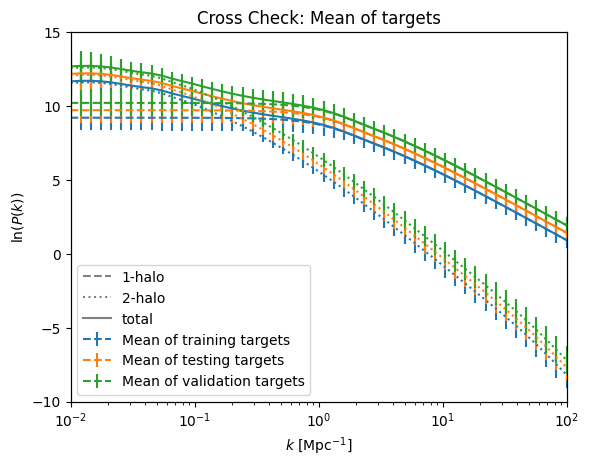

In [14]:
ks = np.geomspace(1e-2, 1e2)

fig, axes=plt.subplots()

plt.xlabel(r'$k$ [Mpc$^{-1}$]')
plt.ylabel(r'$\ln(P(k))$')
plt.title('Cross Check: Mean of targets')


ax2=axes.twinx()
ax2.plot(np.NaN, np.NaN, ls='--', label='1-halo', color='grey')
ax2.plot(np.NaN, np.NaN, ls=':', label='2-halo', color='grey')
ax2.plot(np.NaN, np.NaN, ls='-', label='total', color='grey')




ax2.legend(loc='lower left')


plt.xlim(1e-2,100)
plt.ylim(-10, 15)
axes.set_ylim(-10, 15)
ax2.set_yticks([])
axes.set_xscale('log')
axes.set_yscale('linear')


# Plot training targets
plt.errorbar(ks, mean_training_targets[0], ls='--',
             yerr=std_training_targets[0], color='C0', label='Mean of training targets', fmt='')
plt.errorbar(ks, mean_training_targets[1], ls=':', 
             yerr= std_training_targets[1], color='C0', fmt='')
plt.errorbar(ks, mean_training_targets[2], 
             yerr=std_training_targets[2], color='C0', fmt='')

# Plot testing targets
plt.errorbar(ks, mean_testing_targets[0]+0.5, ls='--',
             yerr=std_testing_targets[0], color='C1', label='Mean of testing targets', fmt='')
plt.errorbar(ks, mean_testing_targets[1]+0.5, ls=':', 
             yerr= std_testing_targets[1], color='C1', fmt='')
plt.errorbar(ks, mean_testing_targets[2]+0.5, 
             yerr=std_testing_targets[2], color='C1', fmt='')

# Plot validation targets
plt.errorbar(ks, mean_validation_targets[0]+1, ls='--',
             yerr=std_validation_targets[0], color='C2', label='Mean of validation targets', fmt='')
plt.errorbar(ks, mean_validation_targets[1]+1, ls=':', 
             yerr= std_validation_targets[1], color='C2', fmt='')
plt.errorbar(ks, mean_validation_targets[2]+1, 
             yerr=std_validation_targets[2], color='C2', fmt='')

plt.legend()
plt.savefig('../Plots/FinalExamples/CrossCheckTargets.png', dpi=600)
plt.show()

In [15]:
mean_training_features = []
std_training_features = []

mean_testing_features = []
std_testing_features = []

mean_validation_features = []
std_validation_features = []

# Funktion zum sicheren Berechnen von Mittelwert und Standardabweichung
def compute_feature_stats(features, name=""):
    mean_list = []
    std_list = []

    if features.ndim != 2 or features.shape[0] == 0:
        print(f"[{name}] Warnung: Features sind leer oder nicht 2D – Statistik wird übersprungen.")
        return mean_list, std_list

    for i in range(features.shape[1]):  # über alle Spalten iterieren
        feature_parameter = features[:, i]

        mean = np.mean(feature_parameter, axis=0)
        std = np.std(feature_parameter, axis=0)

        mean_list.append(mean)
        std_list.append(std)

    return mean_list, std_list

# Für alle drei Datensätze aufrufen
mean_training_features, std_training_features = compute_feature_stats(training_features, name="Training")
mean_testing_features, std_testing_features = compute_feature_stats(testing_features, name="Testing")
mean_validation_features, std_validation_features = compute_feature_stats(validation_features, name="Validation")


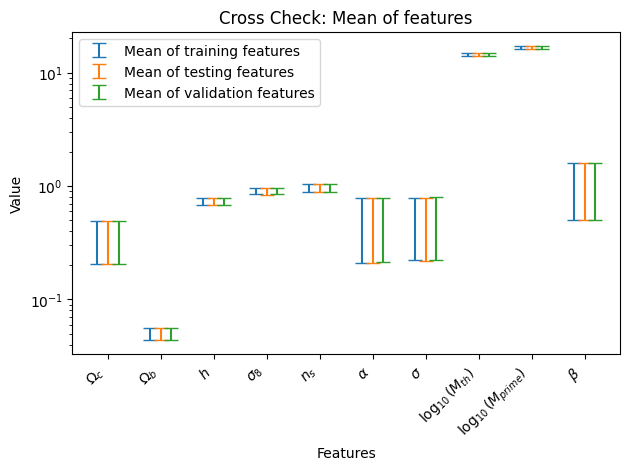

In [16]:
x_pos = np.arange(len(feature_keys))  # numerische Positionen für die x-Werte
offset = 0.2  # Abstand, um die Features ein bisschen zu verschieben

fig, axes = plt.subplots()

axes.set_xlabel('Features')
axes.set_ylabel('Value')
axes.set_title('Cross Check: Mean of features')

# Optional: Y-Achse logarithmisch
axes.set_xscale('linear')
axes.set_yscale('log')

# Training Features
axes.errorbar(x_pos - offset, mean_training_features, 
              yerr=std_training_features, ls='none', 
              color='C0', label='Mean of training features', capsize=5)

# Testing Features
axes.errorbar(x_pos, mean_testing_features, 
              yerr=std_testing_features, ls='none', 
              color='C1', label='Mean of testing features', capsize=5)

# Validation Features
axes.errorbar(x_pos + offset, mean_validation_features, 
              yerr=std_validation_features, ls='none', 
              color='C2', label='Mean of validation features', capsize=5)

# Setze die Original-Feature-Namen als x-Achsen-Beschriftung
axes.set_xticks(x_pos)
axes.set_xticklabels(['$\\Omega_c$', '$\\Omega_b$', '$h$', '$\\sigma_8$', '$n_s$', '$\\alpha$', '$\\sigma$', '$\log_{10}(M_{th})$', '$\log_{10}(M_{prime})$', '$\\beta$' ])
plt.xticks(rotation=45, ha='right')

# Legende
axes.legend()
plt.tight_layout()
plt.subplots_adjust(bottom=0.25)  # Justiere den unteren Rand des Plots
plt.savefig('../Plots/FinalExamples/CrossCheckFeatures.png', dpi=600)
plt.show()

feature_keys = ['Om_c', 'Om_b', 'h', 'sigma_8', 'n_s', 'alpha', 'sigma', 'Mth', 'Mprime', 'beta']

## Renaming

In [17]:
# features
train_targets=training_targets['targets']
test_targets=testing_targets['targets']
val_targets=validation_targets['targets']

## Rescaling
We are rescaling the features by the mean and standard deviation of the training features. Then, they are all scattering by 1 and have a mean value of 0.


In [18]:
# Calculate mean and standard deviation **only from the training data**
target_processing_vectors = {
    'mean': np.mean(train_targets, axis=1, keepdims=True),
    'sigma': np.std(train_targets, axis=1, keepdims=True)
}

# Ensure that no division by zero occurs
target_processing_vectors['sigma'][target_processing_vectors['sigma'] == 0] = 1  

# Preprocessing function
def preprocessing(targets, processing_vectors):
    return (targets - processing_vectors['mean']) / processing_vectors['sigma']

# Postprocessing function
def postprocessing(targets, processing_vectors):
    return targets * processing_vectors['sigma'] + processing_vectors['mean']

# Apply preprocessing to all data
train_targets_rescaled = preprocessing(train_targets, target_processing_vectors)
test_targets_rescaled = preprocessing(test_targets, target_processing_vectors)
val_targets_rescaled = preprocessing(val_targets, target_processing_vectors)

# JSON-compatible storage of the processing vectors
#serializable_processing_vectors = {key: value.tolist() for key, value in processing_vectors.items()}
#processing_out="../Emulators/NM_processing_vectors.json"
#with open(processing_out, "w") as json_file:
#    json.dump(serializable_processing_vectors, json_file)

# Check shapes after the transformation
print("Train Rescaled Shape:", train_targets_rescaled.shape)
print("Test Rescaled Shape:", test_targets_rescaled.shape)
print("Val Rescaled Shape:", val_targets_rescaled.shape)



Train Rescaled Shape: (3, 50000, 50)
Test Rescaled Shape: (3, 940000, 50)
Val Rescaled Shape: (3, 10000, 50)


In [19]:
mean_training_targets_rescaled = []
std_training_targets_rescaled = []

mean_testing_targets_rescaled = []
std_testing_targets_rescaled = []

mean_validation_targets_rescaled = []
std_validation_targets_rescaled = []

# Calculate mean and standard deviation for rescaled training targets
for i in range(len(train_targets_rescaled)):  # for all 3-Halo terms
    halo_data_rescaled = np.array(train_targets_rescaled[i])

    mean = np.mean(halo_data_rescaled, axis=0)  # mean over complete rescaled training sample for every k-value
    std = np.std(halo_data_rescaled, axis=0)    # standard deviation over complete rescaled training sample for every k-value

    mean_training_targets_rescaled.append(mean)
    std_training_targets_rescaled.append(std)

# Calculate mean and standard deviation for rescaled testing targets
for i in range(len(test_targets_rescaled)):  # for all 3-Halo terms
    halo_data_rescaled = np.array(test_targets_rescaled[i])

    mean = np.mean(halo_data_rescaled, axis=0)  # mean over complete rescaled testing sample for every k-value
    std = np.std(halo_data_rescaled, axis=0)    # standard deviation over complete rescaled testing sample for every k-value

    mean_testing_targets_rescaled.append(mean)
    std_testing_targets_rescaled.append(std)

# Calculate mean and standard deviation for rescaled validation targets
for i in range(len(val_targets_rescaled)):  # for all 3-Halo terms
    halo_data_rescaled = np.array(val_targets_rescaled[i])

    mean = np.mean(halo_data_rescaled, axis=0)  # mean over complete rescaled validation sample for every k-value
    std = np.std(halo_data_rescaled, axis=0)    # standard deviation over complete rescaled validation sample for every k-value

    mean_validation_targets_rescaled.append(mean)
    std_validation_targets_rescaled.append(std)

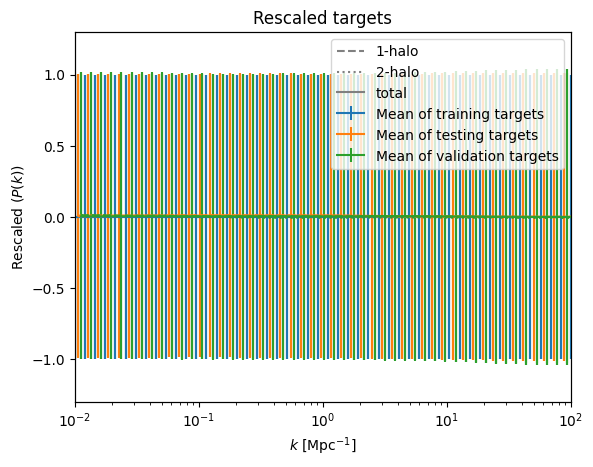

In [20]:
fig, axes=plt.subplots()
#axes.loglog(ks, Pk_lin, color='k', label='linear')
plt.xlabel(r'$k$ [Mpc$^{-1}$]')
plt.ylabel(r'Rescaled $(P(k))$')
plt.title('Rescaled targets')

ax2=axes.twinx()
ax2.plot(np.NaN, np.NaN, ls='--', label='1-halo', color='grey')
ax2.plot(np.NaN, np.NaN, ls=':', label='2-halo', color='grey')
ax2.plot(np.NaN, np.NaN, ls='-', label='total', color='grey')
ax2.set_yticks([])



plt.errorbar(ks,mean_training_targets_rescaled[0], 
             yerr=std_training_targets_rescaled[0], color='C0', label='Mean of training targets')
plt.errorbar(ks,mean_training_targets_rescaled[1], ls=':', 
             yerr=std_training_targets_rescaled[1], color='C0')
plt.errorbar(ks,mean_training_targets_rescaled[2], ls='--', 
             yerr=std_training_targets_rescaled[2], color='C0')

plt.errorbar(ks*1.06,mean_testing_targets_rescaled[0], 
             yerr=std_testing_targets_rescaled[0], color='C1', label='Mean of testing targets')
plt.errorbar(ks*1.06,mean_testing_targets_rescaled[1], ls=':', 
             yerr=std_testing_targets_rescaled[1], color='C1')
plt.errorbar(ks*1.06,mean_testing_targets_rescaled[2], ls='--', 
             yerr=std_testing_targets_rescaled[2], color='C1')

plt.errorbar(ks*1.12,mean_validation_targets_rescaled[0], 
             yerr=std_validation_targets_rescaled[0], color='C2', label='Mean of validation targets')
plt.errorbar(ks*1.12,mean_validation_targets_rescaled[1], ls=':', 
             yerr=std_validation_targets_rescaled[1], color='C2')
plt.errorbar(ks*1.12,mean_validation_targets_rescaled[2], ls='--', 
             yerr=std_validation_targets_rescaled[2], color='C2')

axes.set_ylim(-1.3, 1.3)
plt.xlim(1e-2,100)
plt.ylim(-1.3,1.3)
plt.xscale('log')
plt.legend()
plt.savefig('../Plots/FinalExamples/RescaledTargets.png', dpi=600)

In [21]:
# Calculate mean and standard deviation **only from the training data**
feature_processing_vectors = {
    'mean': np.array(mean_training_features).reshape(1, -1),
    'sigma': np.array(std_training_features).reshape(1, -1)
}


# Ensure that no division by zero occurs
feature_processing_vectors['sigma'][feature_processing_vectors['sigma'] == 0] = 1  

# Preprocessing function
def preprocessing(features, processing_vectors):
    return (features - processing_vectors['mean']) / processing_vectors['sigma']

# Postprocessing function
def postprocessing(features, processing_vectors):
    return features * processing_vectors['sigma'] + processing_vectors['mean']

# Apply preprocessing to all data
train_features_rescaled = preprocessing(training_features, feature_processing_vectors)
test_features_rescaled = preprocessing(testing_features, feature_processing_vectors)
val_features_rescaled = preprocessing(validation_features, feature_processing_vectors)

# JSON-compatible storage of the processing vectors
#serializable_processing_vectors = {key: value.tolist() for key, value in processing_vectors.items()}
#processing_out="../Emulators/NM_processing_vectors.json"
#with open(processing_out, "w") as json_file:
#    json.dump(serializable_processing_vectors, json_file)

# Check shapes after the transformation
print("Train Rescaled Shape:", train_features_rescaled.shape)
print("Test Rescaled Shape:", test_features_rescaled.shape)
print("Val Rescaled Shape:", val_features_rescaled.shape)



Train Rescaled Shape: (50000, 10)
Test Rescaled Shape: (940000, 10)
Val Rescaled Shape: (10000, 10)


In [22]:


mean_training_features_rescaled = []
std_training_features_rescaled = []

mean_testing_features_rescaled = []
std_testing_features_rescaled = []

mean_validation_features_rescaled = []
std_validation_features_rescaled = []


# Calculate mean and standard deviation for training features
for i in range(len(train_features_rescaled[0])):  # for all 3-Halo terms
    feature_parameter = np.array(train_features_rescaled[:,i])
    
    mean = np.mean(feature_parameter, axis=0)  # mean over complete training sample for every k-value
    std = np.std(feature_parameter, axis=0)    # standard deviation over complete training sample for every k-value
    mean_training_features_rescaled.append(mean)
    std_training_features_rescaled.append(std)

# Calculate mean and standard deviation for testing features
for i in range(len(test_features_rescaled[0])):  # for all 3-Halo terms
    feature_parameter = np.array(test_features_rescaled[:,i])

    mean = np.mean(feature_parameter, axis=0) # mean over complete testing sample for every k-value
    std = np.std(feature_parameter, axis=0)    # standard deviation over complete testing sample for every k-value

    mean_testing_features_rescaled.append(mean)
    std_testing_features_rescaled.append(std)

# Calculate mean and standard deviation for validation features
for i in range(len(val_features_rescaled[0])):  # for all 3-Halo terms
    feature_parameter = np.array(val_features_rescaled[:,i])

    mean = np.mean(feature_parameter, axis=0)  # mean over complete validation sample for every k-value
    std = np.std(feature_parameter, axis=0)    # standard deviation over complete validation sample for every k-value

    mean_validation_features_rescaled.append(mean)
    std_validation_features_rescaled.append(std)

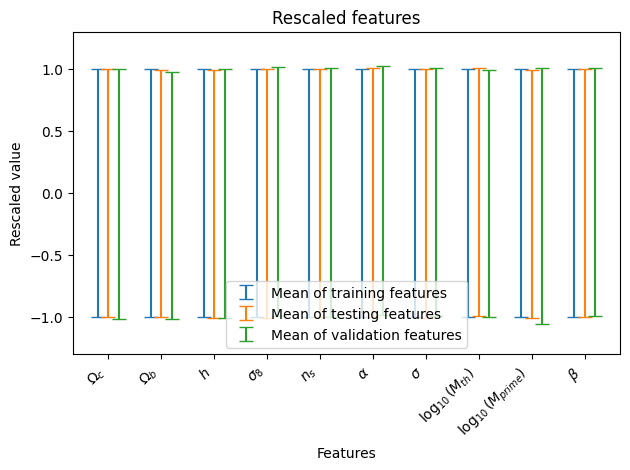

In [23]:
x_pos = np.arange(len(feature_keys))  # numerische Positionen für die x-Werte
offset = 0.2  # Abstand, um die Features ein bisschen zu verschieben

fig, axes = plt.subplots()

axes.set_xlabel('Features')
axes.set_ylabel('Rescaled value')
axes.set_title('Rescaled features')

# Optional: Y-Achse logarithmisch
axes.set_xscale('linear')
axes.set_yscale('linear')

# Training Features
axes.errorbar(x_pos - offset, mean_training_features_rescaled, 
              yerr=std_training_features_rescaled, ls='none', 
              color='C0', label='Mean of training features', capsize=5)

# Testing Features
axes.errorbar(x_pos, mean_testing_features_rescaled, 
              yerr=std_testing_features_rescaled, ls='none', 
              color='C1', label='Mean of testing features', capsize=5)

# Validation Features
axes.errorbar(x_pos + offset, mean_validation_features_rescaled, 
              yerr=std_validation_features_rescaled, ls='none', 
              color='C2', label='Mean of validation features', capsize=5)

# Setze die Original-Feature-Namen als x-Achsen-Beschriftung
axes.set_xticks(x_pos)
axes.set_xticklabels(['$\\Omega_c$', '$\\Omega_b$', '$h$', '$\\sigma_8$', '$n_s$', '$\\alpha$', '$\\sigma$', '$\log_{10}(M_{th})$', '$\log_{10}(M_{prime})$', '$\\beta$' ])
plt.xticks(rotation=45, ha='right')


axes.set_ylim(-1.3, 1.3)
plt.ylim(-1.3,1.3)
# Legende
plt.legend()

plt.tight_layout()
plt.subplots_adjust(bottom=0.25)  # Justiere den unteren Rand des Plots
plt.savefig('../Plots/FinalExamples/RescaledFeatures.png', dpi=600)
plt.show()

In [ ]:
#restructuring of the arrays
train_targets_rescaled = np.transpose(train_targets_rescaled, (1, 0, 2))
val_targets_rescaled = np.transpose(val_targets_rescaled, (1, 0, 2))
test_targets_rescaled = np.transpose(test_targets_rescaled, (1, 0, 2))


In [25]:
N_total = len(clean_samples)

In [26]:
# Modell-Zeitstempel (Dateinamen)

model1_date='2025-06-24_11-16-02' #test loss=0.001483, val loss=0.001149, params={'n_layers': 14, 'n_units': 888, 'activation': 'gelu', 'optimizer': 'RAdam', 'lr': 0.00049, 'batchsize': 1889}

model2_1halo_date='2025-06-15_02-54-08' #test loss=0.001870, val loss=0.001281, params={'n_layers': 10, 'n_units': 416, 'activation': 'gelu', 'optimizer': 'adam', 'lr': 0.001, 'batchsize': 1717}
model2_2halo_date='2025-06-18_00-05-20' #test loss=0.000790, val loss=0.000455, params={'n_layers': 13, 'n_units': 165, 'activation': 'swish', 'optimizer': 'adam', 'lr': 0.000997, 'batchsize': 1313}

model3_date='2025-05-18_18-07-15' #test loss=0.001998, validation loss=0.001020, params={'n_layers': 3, 'n_units': 478, 'activation': 'elu', 'optimizer': 'RAdam', 'lr': 0.00011, 'batchsize': 1712}

model4_1halo_date='2025-06-06_17-39-22' #test loss=0.004405, val loss=0.001415, params={'n_layers': 3, 'n_units': 432, 'activation': 'swish', 'optimizer': 'adam', 'lr': 0.0027, 'batchsize': 752}
model4_2halo_date='2025-06-19_11-58-01' #test loss=0.001681, val loss=0.001320, params={'n_layers': 2, 'n_units': 639, 'activation': 'swish', 'optimizer': 'adam', 'lr': 0.00208, 'batchsize': 1397}


# Modelle laden und kompilieren
model1 = keras.models.load_model(
    f'../NN_builds/NN_{model1_date}.keras',
    compile=False
)
model1.compile(optimizer=RectifiedAdam(), loss='mse')

model2_1halo = keras.models.load_model(
    f'../NN_builds/NN_{model2_1halo_date}.keras',
    compile=False
)
model2_1halo.compile(optimizer=RectifiedAdam(), loss='mse')

model2_2halo = keras.models.load_model(
    f'../NN_builds/NN_{model2_2halo_date}.keras',
    compile=False
)
model2_2halo.compile(optimizer=RectifiedAdam(), loss='mse')

model3 = keras.models.load_model(
    f'../NN_builds/NN_{model3_date}.keras',
    compile=False
)
model3.compile(optimizer=RectifiedAdam(), loss='mse')

model4_1halo = keras.models.load_model(
    f'../NN_builds/NN_{model4_1halo_date}.keras',
    compile=False
)
model4_1halo.compile(optimizer=RectifiedAdam(), loss='mse')

model4_2halo = keras.models.load_model(
    f'../NN_builds/NN_{model4_2halo_date}.keras',
    compile=False
)
model4_2halo.compile(optimizer=RectifiedAdam(), loss='mse')


# Trainingsverläufe laden
with open(f'../Traininghist/full_training_history_{model1_date}.json', 'r') as f:
    loaded_history_1 = json.load(f)

with open(f'../Traininghist/full_training_history_{model2_1halo_date}.json', 'r') as f:
    loaded_history_21 = json.load(f)

with open(f'../Traininghist/full_training_history_{model2_2halo_date}.json', 'r') as f:
    loaded_history_22 = json.load(f)

with open(f'../Traininghist/full_training_history_{model3_date}.json', 'r') as f:
    loaded_history_3 = json.load(f)

with open(f'../Traininghist/full_training_history_{model4_1halo_date}.json', 'r') as f:
    loaded_history_41 = json.load(f)

with open(f'../Traininghist/full_training_history_{model4_2halo_date}.json', 'r') as f:
    loaded_history_42 = json.load(f)

In [27]:
# Modellzusammenfassungen
print("\n--- Modell 1 ---")
model1.summary()

print("\n--- Modell 2 – 1-Halo ---")
model2_1halo.summary()

print("\n--- Modell 2 – 2-Halo ---")
model2_2halo.summary()

print("\n--- Modell 3 ---")
model3.summary()

print("\n--- Modell 4 – 1-Halo ---")
model4_1halo.summary()

print("\n--- Modell 4 – 2-Halo ---")
model4_2halo.summary()



--- Modell 1 ---
Model: "sequential_85"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_1055 (Dense)          (None, 888)               9768      
                                                                 
 dense_1056 (Dense)          (None, 888)               789432    
                                                                 
 dense_1057 (Dense)          (None, 888)               789432    
                                                                 
 dense_1058 (Dense)          (None, 888)               789432    
                                                                 
 dense_1059 (Dense)          (None, 888)               789432    
                                                                 
 dense_1060 (Dense)          (None, 888)               789432    
                                                                 
 dense_1061 (Dense)          (None,

1/1 [==============================] - 7s 7s/step - loss: 0.0011
0.0011120140552520752


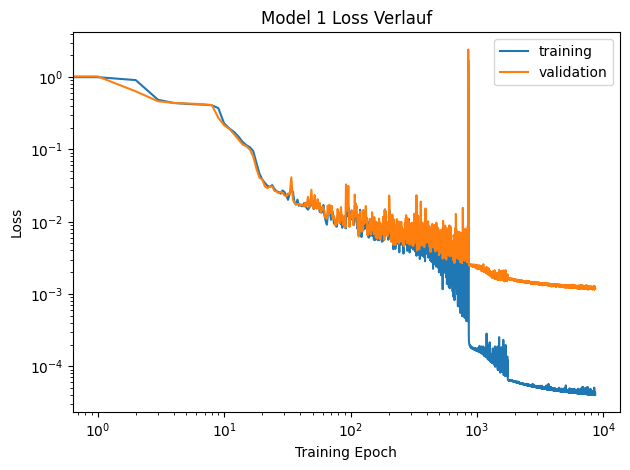

In [ ]:
test_loss_1 = model1.evaluate(test_features_rescaled, test_targets_rescaled.reshape((N_test, 150)), batch_size=N_total)
print(test_loss_1)

fig, ax = plt.subplots()
ax.plot(loaded_history_1['loss'], label='training')
ax.plot(loaded_history_1['val_loss'], label='validation', alpha=1)
ax.set_ylabel('Loss')
ax.set_xlabel('Training Epoch')
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_title('Model 1 training process')

plt.legend()
plt.tight_layout()
# plt.savefig(f'../Plots/Loss_{model1_date}.pdf')  # optional
plt.show()


1/1 [==============================] - 1s 822ms/step - loss: 6.2794e-04
0.001463574473746121
0.0006279426161199808


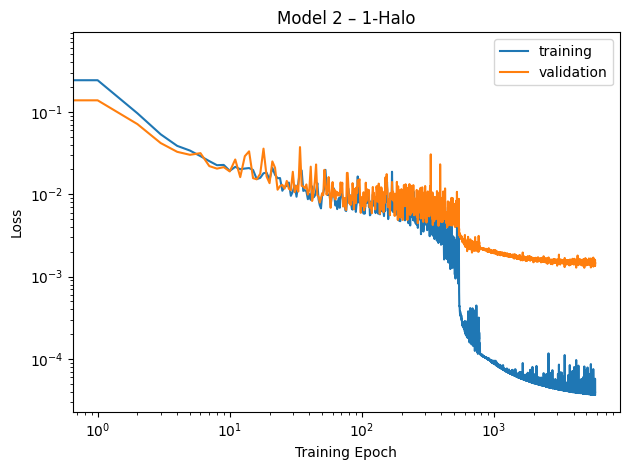

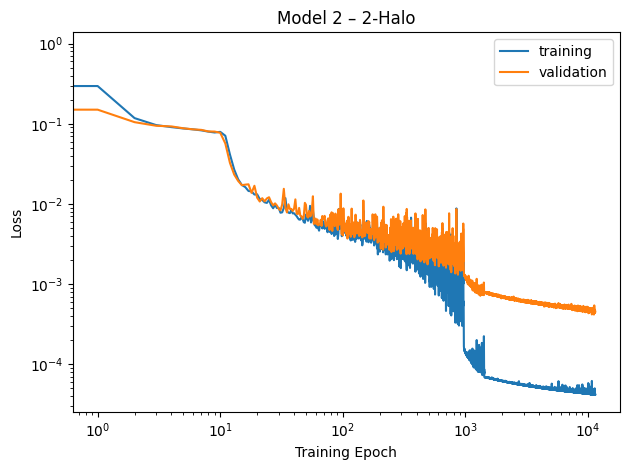

In [ ]:
test_loss_21 = model2_1halo.evaluate(test_features_rescaled, test_targets_rescaled[:, 0], batch_size=N_total)
test_loss_22 = model2_2halo.evaluate(test_features_rescaled, test_targets_rescaled[:, 1], batch_size=N_total)

print(test_loss_21)
print(test_loss_22)
test_loss_2 = test_loss_21 + test_loss_22

fig, ax = plt.subplots()
ax.plot(loaded_history_21['loss'], label='training')
ax.plot(loaded_history_21['val_loss'], label='validation', alpha=1)
ax.set_ylabel('Loss')
ax.set_xlabel('Training Epoch')
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_title('Model 2 training process – 1-Halo')

plt.legend()
plt.tight_layout()
# plt.savefig(f'../Plots/Loss_{model2_1halo_date}.pdf')
plt.show()

fig, ax = plt.subplots()
ax.plot(loaded_history_22['loss'], label='training')
ax.plot(loaded_history_22['val_loss'], label='validation', alpha=1)
ax.set_ylabel('Loss')
ax.set_xlabel('Training Epoch')
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_title('Model 2 training process – 2-Halo')

plt.legend()
plt.tight_layout()
# plt.savefig(f'../Plots/Loss_{model2_2halo_date}.pdf')
plt.show()


1/1 [==============================] - 1s 676ms/step - loss: 0.0016
0.0015824198490008712


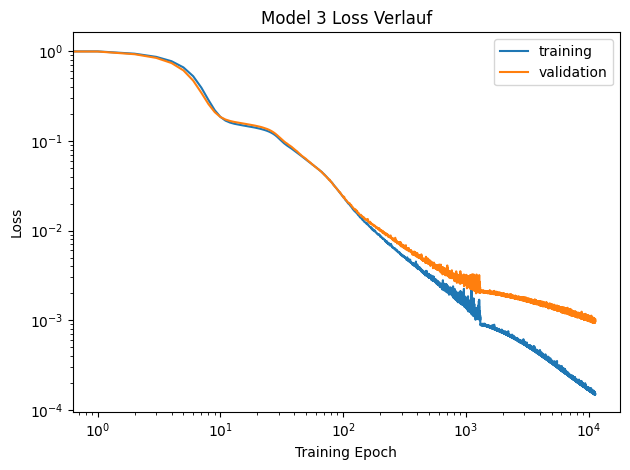

In [ ]:
test_loss_3 = model3.evaluate(test_features_rescaled, test_targets_rescaled.reshape((N_test, 150)), batch_size=N_total)
print(test_loss_3)

fig, ax = plt.subplots()
ax.plot(loaded_history_3['loss'], label='training')
ax.plot(loaded_history_3['val_loss'], label='validation', alpha=1)
ax.set_ylabel('Loss')
ax.set_xlabel('Training Epoch')
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_title('Model 3 training process')

plt.legend()
plt.tight_layout()
# plt.savefig(f'../Plots/Loss_{model3_date}.pdf')  # optional
plt.show()


1/1 [==============================] - 1s 548ms/step - loss: 0.0015
0.0030720403883606195
0.0015116288559511304


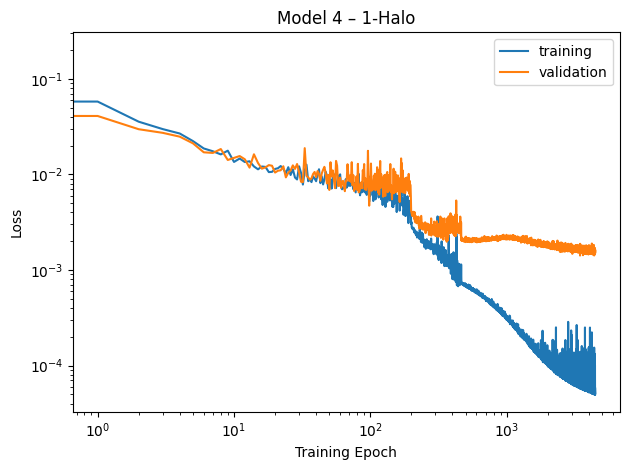

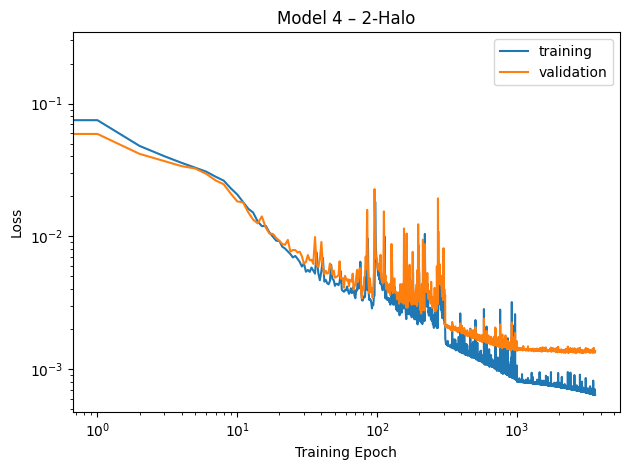

In [ ]:
test_loss_41 = model4_1halo.evaluate(test_features_rescaled, test_targets_rescaled[:, 0], batch_size=N_total)
test_loss_42 = model4_2halo.evaluate(test_features_rescaled, test_targets_rescaled[:, 1], batch_size=N_total)

print(test_loss_41)
print(test_loss_42)

test_loss_4 = test_loss_41 + test_loss_42

fig, ax = plt.subplots()
ax.plot(loaded_history_41['loss'], label='training')
ax.plot(loaded_history_41['val_loss'], label='validation', alpha=1)
ax.set_ylabel('Loss')
ax.set_xlabel('Training Epoch')
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_title('Model 4 training process – 1-Halo')

plt.legend()
plt.tight_layout()
# plt.savefig(f'../Plots/Loss_{model4_1halo_date}.pdf')
plt.show()

fig, ax = plt.subplots()
ax.plot(loaded_history_42['loss'], label='training')
ax.plot(loaded_history_42['val_loss'], label='validation', alpha=1)
ax.set_ylabel('Loss')
ax.set_xlabel('Training Epoch')
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_title('Model 4 training process – 2-Halo')

plt.legend()
plt.tight_layout()
# plt.savefig(f'../Plots/Loss_{model4_2halo_date}.pdf')
plt.show()


In [32]:
# === Model Outputs vorbereiten ===

# Model 1
emulated_testing1 = np.array(model1.predict(test_features_rescaled, batch_size=N_total))
print("emulated_testing1:", emulated_testing1.shape)
pred_testing_targets1 = emulated_testing1.reshape(N_test, 3, 50).transpose(1, 0, 2)
print("pred_testing_targets1:", pred_testing_targets1.shape)
postprocessed_pred_testing_targets1 = postprocessing(pred_testing_targets1, target_processing_vectors)
print("postprocessed_pred_testing_targets1:", postprocessed_pred_testing_targets1.shape)

# Model 2 - 1-Halo
emulated_testing21 = np.array(model2_1halo.predict(test_features_rescaled, batch_size=N_total))
print("emulated_testing21:", emulated_testing21.shape)
pred_testing_targets21 = emulated_testing21.reshape(N_test, 50)
print("pred_testing_targets21:", pred_testing_targets21.shape)
postprocessed_pred_testing_targets21 = postprocessing(pred_testing_targets21, target_processing_vectors)
print("postprocessed_pred_testing_targets21:", postprocessed_pred_testing_targets21.shape)

# Model 2 - 2-Halo
emulated_testing22 = np.array(model2_2halo.predict(test_features_rescaled, batch_size=N_total))
print("emulated_testing22:", emulated_testing22.shape)
pred_testing_targets22 = emulated_testing22.reshape(N_test, 50)
print("pred_testing_targets22:", pred_testing_targets22.shape)
postprocessed_pred_testing_targets22 = postprocessing(pred_testing_targets22, target_processing_vectors)
print("postprocessed_pred_testing_targets22:", postprocessed_pred_testing_targets22.shape)

# Model 3
emulated_testing3 = np.array(model3.predict(test_features_rescaled, batch_size=N_total))
print("emulated_testing3:", emulated_testing3.shape)
pred_testing_targets3 = emulated_testing3.reshape(N_test, 3, 50).transpose(1, 0, 2)
print("pred_testing_targets3:", pred_testing_targets3.shape)
postprocessed_pred_testing_targets3 = postprocessing(pred_testing_targets3, target_processing_vectors)
print("postprocessed_pred_testing_targets3:", postprocessed_pred_testing_targets3.shape)

# Model 4 - 1-Halo
emulated_testing41 = np.array(model4_1halo.predict(test_features_rescaled, batch_size=N_total))
print("emulated_testing41:", emulated_testing41.shape)
pred_testing_targets41 = emulated_testing41.reshape(N_test, 50)
print("pred_testing_targets41:", pred_testing_targets41.shape)
postprocessed_pred_testing_targets41 = postprocessing(pred_testing_targets41, target_processing_vectors)
print("postprocessed_pred_testing_targets41:", postprocessed_pred_testing_targets41.shape)

# Model 4 - 2-Halo
emulated_testing42 = np.array(model4_2halo.predict(test_features_rescaled, batch_size=N_total))
print("emulated_testing42:", emulated_testing42.shape)
pred_testing_targets42 = emulated_testing42.reshape(N_test, 50)
print("pred_testing_targets42:", pred_testing_targets42.shape)
postprocessed_pred_testing_targets42 = postprocessing(pred_testing_targets42, target_processing_vectors)
print("postprocessed_pred_testing_targets42:", postprocessed_pred_testing_targets42.shape)


1/1 [==============================] - 7s 7s/step
emulated_testing1: (940000, 150)
pred_testing_targets1: (3, 940000, 50)
postprocessed_pred_testing_targets1: (3, 940000, 50)
1/1 [==============================] - 2s 2s/step
emulated_testing21: (940000, 50)
pred_testing_targets21: (940000, 50)
postprocessed_pred_testing_targets21: (3, 940000, 50)
1/1 [==============================] - 1s 590ms/step
emulated_testing22: (940000, 50)
pred_testing_targets22: (940000, 50)
postprocessed_pred_testing_targets22: (3, 940000, 50)
1/1 [==============================] - 0s 408ms/step
emulated_testing3: (940000, 150)
pred_testing_targets3: (3, 940000, 50)
postprocessed_pred_testing_targets3: (3, 940000, 50)
1/1 [==============================] - 0s 434ms/step
emulated_testing41: (940000, 50)
pred_testing_targets41: (940000, 50)
postprocessed_pred_testing_targets41: (3, 940000, 50)
1/1 [==============================] - 0s 449ms/step
emulated_testing42: (940000, 50)
pred_testing_targets42: (940000, 

In [33]:
# === Model 1 ===
diff_1h_1 = np.abs(postprocessed_pred_testing_targets1[0, :, :] / test_targets[0, :, :] - 1)
diff_2h_1 = np.abs(postprocessed_pred_testing_targets1[1, :, :] / test_targets[1, :, :] - 1)
diff_total_1 = np.abs(postprocessed_pred_testing_targets1[2, :, :] / test_targets[2, :, :] - 1)

percentiles_1h_test1 = np.zeros((4, 50))
percentiles_2h_test1 = np.zeros((4, 50))
percentiles_total_test1 = np.zeros((4, 50))

percentiles_1h_test1[0] = np.percentile(diff_1h_1, 68, axis=0)
percentiles_1h_test1[1] = np.percentile(diff_1h_1, 95, axis=0)
percentiles_1h_test1[2] = np.percentile(diff_1h_1, 99, axis=0)
percentiles_1h_test1[3] = np.percentile(diff_1h_1, 99.9, axis=0)

percentiles_2h_test1[0] = np.percentile(diff_2h_1, 68, axis=0)
percentiles_2h_test1[1] = np.percentile(diff_2h_1, 95, axis=0)
percentiles_2h_test1[2] = np.percentile(diff_2h_1, 99, axis=0)
percentiles_2h_test1[3] = np.percentile(diff_2h_1, 99.9, axis=0)

percentiles_total_test1[0] = np.percentile(diff_total_1, 68, axis=0)
percentiles_total_test1[1] = np.percentile(diff_total_1, 95, axis=0)
percentiles_total_test1[2] = np.percentile(diff_total_1, 99, axis=0)
percentiles_total_test1[3] = np.percentile(diff_total_1, 99.9, axis=0)


# === Model 2 ===
# ACHTUNG: postprocessed_pred_testing_targets21/22 Shape: (3, 9800, 50) – nehme den 1. Kanal für 1-Halo, 2. für 2-Halo
diff_1h_2 = np.abs(postprocessed_pred_testing_targets21[0, :, :] / test_targets[0, :, :] - 1)
diff_2h_2 = np.abs(postprocessed_pred_testing_targets22[1, :, :] / test_targets[1, :, :] - 1)
diff_total_2 = np.abs(np.log(np.exp(postprocessed_pred_testing_targets21[0, :, :]) + np.exp(postprocessed_pred_testing_targets22[1, :, :])) / test_targets[2, :, :] - 1)

percentiles_1h_test2 = np.zeros((4, 50))
percentiles_2h_test2 = np.zeros((4, 50))
percentiles_total_test2 = np.zeros((4, 50))

percentiles_1h_test2[0] = np.percentile(diff_1h_2, 68, axis=0)
percentiles_1h_test2[1] = np.percentile(diff_1h_2, 95, axis=0)
percentiles_1h_test2[2] = np.percentile(diff_1h_2, 99, axis=0)
percentiles_1h_test2[3] = np.percentile(diff_1h_2, 99.9, axis=0)

percentiles_2h_test2[0] = np.percentile(diff_2h_2, 68, axis=0)
percentiles_2h_test2[1] = np.percentile(diff_2h_2, 95, axis=0)
percentiles_2h_test2[2] = np.percentile(diff_2h_2, 99, axis=0)
percentiles_2h_test2[3] = np.percentile(diff_2h_2, 99.9, axis=0)

percentiles_total_test2[0] = np.percentile(diff_total_2, 68, axis=0)
percentiles_total_test2[1] = np.percentile(diff_total_2, 95, axis=0)
percentiles_total_test2[2] = np.percentile(diff_total_2, 99, axis=0)
percentiles_total_test2[3] = np.percentile(diff_total_2, 99.9, axis=0)


# === Model 3 ===
diff_1h_3 = np.abs(postprocessed_pred_testing_targets3[0, :, :] / test_targets[0, :, :] - 1)
diff_2h_3 = np.abs(postprocessed_pred_testing_targets3[1, :, :] / test_targets[1, :, :] - 1)
diff_total_3 = np.abs(postprocessed_pred_testing_targets3[2, :, :] / test_targets[2, :, :] - 1)

percentiles_1h_test3 = np.zeros((4, 50))
percentiles_2h_test3 = np.zeros((4, 50))
percentiles_total_test3 = np.zeros((4, 50))

percentiles_1h_test3[0] = np.percentile(diff_1h_3, 68, axis=0)
percentiles_1h_test3[1] = np.percentile(diff_1h_3, 95, axis=0)
percentiles_1h_test3[2] = np.percentile(diff_1h_3, 99, axis=0)
percentiles_1h_test3[3] = np.percentile(diff_1h_3, 99.9, axis=0)

percentiles_2h_test3[0] = np.percentile(diff_2h_3, 68, axis=0)
percentiles_2h_test3[1] = np.percentile(diff_2h_3, 95, axis=0)
percentiles_2h_test3[2] = np.percentile(diff_2h_3, 99, axis=0)
percentiles_2h_test3[3] = np.percentile(diff_2h_3, 99.9, axis=0)

percentiles_total_test3[0] = np.percentile(diff_total_3, 68, axis=0)
percentiles_total_test3[1] = np.percentile(diff_total_3, 95, axis=0)
percentiles_total_test3[2] = np.percentile(diff_total_3, 99, axis=0)
percentiles_total_test3[3] = np.percentile(diff_total_3, 99.9, axis=0)


# === Model 4 ===
diff_1h_4 = np.abs(postprocessed_pred_testing_targets41[0, :, :] / test_targets[0, :, :] - 1)
diff_2h_4 = np.abs(postprocessed_pred_testing_targets42[1, :, :] / test_targets[1, :, :] - 1)
diff_total_4 = np.abs(np.log(np.exp(postprocessed_pred_testing_targets41[0, :, :]) + np.exp(postprocessed_pred_testing_targets42[1, :, :])) / test_targets[2, :, :] - 1)

percentiles_1h_test4 = np.zeros((4, 50))
percentiles_2h_test4 = np.zeros((4, 50))
percentiles_total_test4 = np.zeros((4, 50))

percentiles_1h_test4[0] = np.percentile(diff_1h_4, 68, axis=0)
percentiles_1h_test4[1] = np.percentile(diff_1h_4, 95, axis=0)
percentiles_1h_test4[2] = np.percentile(diff_1h_4, 99, axis=0)
percentiles_1h_test4[3] = np.percentile(diff_1h_4, 99.9, axis=0)

percentiles_2h_test4[0] = np.percentile(diff_2h_4, 68, axis=0)
percentiles_2h_test4[1] = np.percentile(diff_2h_4, 95, axis=0)
percentiles_2h_test4[2] = np.percentile(diff_2h_4, 99, axis=0)
percentiles_2h_test4[3] = np.percentile(diff_2h_4, 99.9, axis=0)

percentiles_total_test4[0] = np.percentile(diff_total_4, 68, axis=0)
percentiles_total_test4[1] = np.percentile(diff_total_4, 95, axis=0)
percentiles_total_test4[2] = np.percentile(diff_total_4, 99, axis=0)
percentiles_total_test4[3] = np.percentile(diff_total_4, 99.9, axis=0)


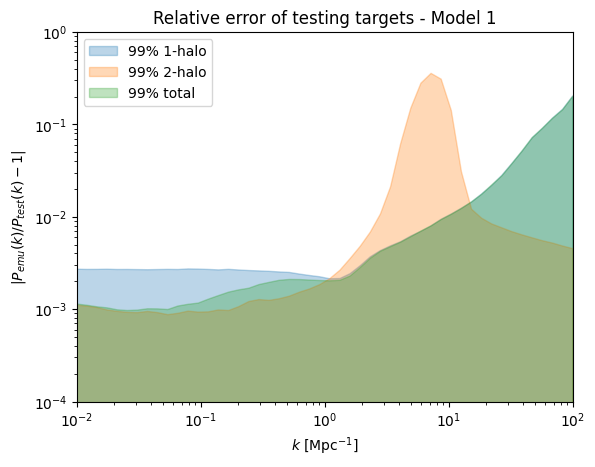

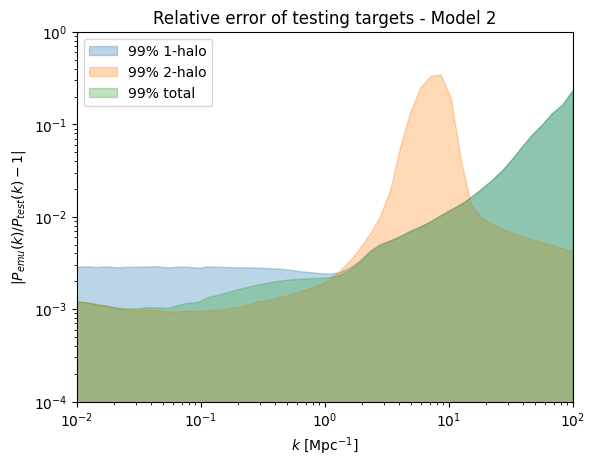

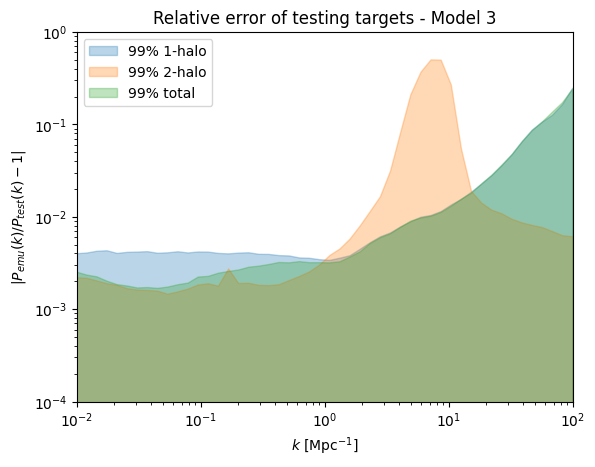

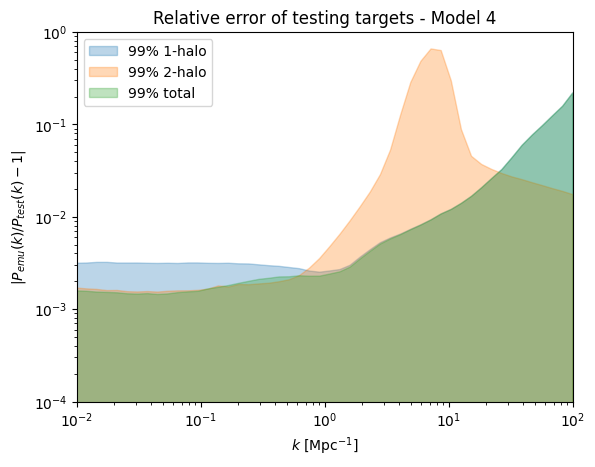

In [ ]:
def plot_model_percentiles(percentiles_1h, percentiles_2h, percentiles_total, model_name, ks):
    fig, ax = plt.subplots()

    ax.fill_between(ks, 0, percentiles_1h[2, :], color='C0', alpha=0.3, label=r'99% percentile 1-halo')
    ax.fill_between(ks, 0, percentiles_2h[2, :], color='C1', alpha=0.3, label=r'99% percentile 2-halo')
    ax.fill_between(ks, 0, percentiles_total[2, :], color='C2', alpha=0.3, label=r'99% percentile total')

    ax.set_xscale('log')
    ax.set_yscale('log')

    ax.set_xlim(1e-2, 100)
    ax.set_ylim(1e-4, 1)

    ax.set_ylabel(r'$P_\mathrm{emu}(k)/P_\mathrm{test}(k)-1$')
    ax.set_xlabel(r'$k$ [Mpc$^{-1}$]')
    ax.set_title(f'Relative error of testing targets - {model_name}')

    ax.legend()
    plt.show()

plot_model_percentiles(percentiles_1h_test1, percentiles_2h_test1, percentiles_total_test1, "Model 1", ks)
plot_model_percentiles(percentiles_1h_test2, percentiles_2h_test2, percentiles_total_test2, "Model 2", ks)
plot_model_percentiles(percentiles_1h_test3, percentiles_2h_test3, percentiles_total_test3, "Model 3", ks)
plot_model_percentiles(percentiles_1h_test4, percentiles_2h_test4, percentiles_total_test4, "Model 4", ks)



In [36]:
def arrays_are_exactly_equal(arr1, arr2):
    if arr1.shape != arr2.shape:
        print(f"Unterschiedliche Shapes: {arr1.shape} vs {arr2.shape}")
        return False
    if np.array_equal(arr1, arr2):
        print("Arrays sind exakt gleich.")
        return True
    else:
        print("Arrays sind nicht exakt gleich.")
        return False

print(arrays_are_exactly_equal(percentiles_total_test1, percentiles_total_test3))


Arrays sind nicht exakt gleich.
False


In [37]:
# Model 1
test_max_error_per_sample_1 = np.sum(np.abs(diff_total_1), axis=1)
worst_dataset_index_1 = np.argmax(test_max_error_per_sample_1)
print(f"Model 1 - Schlechtester Datensatz: {worst_dataset_index_1}, Fehler: {test_max_error_per_sample_1[worst_dataset_index_1]:.4f}")

# Model 2
test_max_error_per_sample_2 = np.sum(np.abs(diff_total_2), axis=1)
worst_dataset_index_2 = np.argmax(test_max_error_per_sample_2)
print(f"Model 2 - Schlechtester Datensatz: {worst_dataset_index_2}, Fehler: {test_max_error_per_sample_2[worst_dataset_index_2]:.4f}")

# Model 3
test_max_error_per_sample_3 = np.sum(np.abs(diff_total_3), axis=1)
worst_dataset_index_3 = np.argmax(test_max_error_per_sample_3)
print(f"Model 3 - Schlechtester Datensatz: {worst_dataset_index_3}, Fehler: {test_max_error_per_sample_3[worst_dataset_index_3]:.4f}")

# Model 4
test_max_error_per_sample_4 = np.sum(np.abs(diff_total_4), axis=1)
worst_dataset_index_4 = np.argmax(test_max_error_per_sample_4)
print(f"Model 4 - Schlechtester Datensatz: {worst_dataset_index_4}, Fehler: {test_max_error_per_sample_4[worst_dataset_index_4]:.4f}")


Model 1 - Schlechtester Datensatz: 816323, Fehler: 82951.2213
Model 2 - Schlechtester Datensatz: 816323, Fehler: 152277.9048
Model 3 - Schlechtester Datensatz: 816323, Fehler: 136306.8953
Model 4 - Schlechtester Datensatz: 816323, Fehler: 52676.0600


(940000, 50)
(940000, 50)


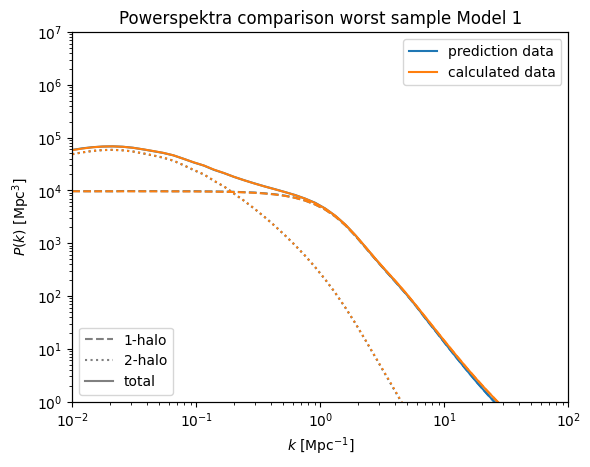

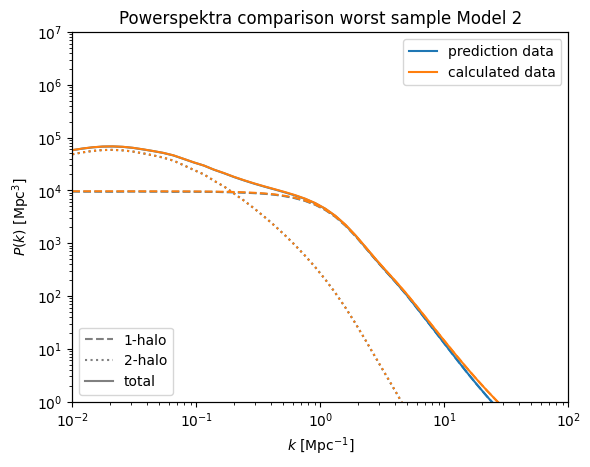

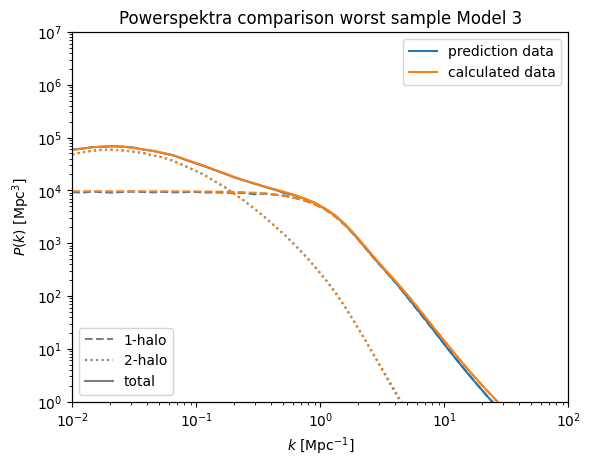

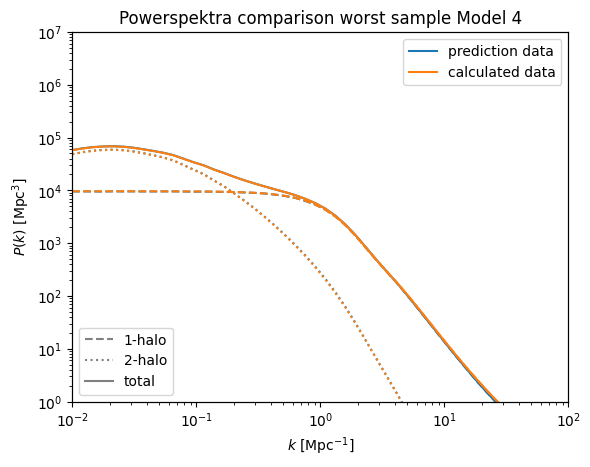

In [ ]:
print(postprocessed_pred_testing_targets1[0, :, :].shape)
print(postprocessed_pred_testing_targets21[0, :, :].shape)

def plot_worst_sample(model_num, postprocessed_preds_1h, postprocessed_preds_2h, postprocessed_preds_total, test_targets, worst_idx, ks):
    fig, axes = plt.subplots()

    if model_num in [2, 4]:
        # Für Modelle 2 und 4: 1-halo und 2-halo Term sind separat, total ist log(exp(1h)+exp(2h))
        axes.loglog(ks, np.exp(postprocessed_preds_1h[0, worst_idx, :]), color='C0', ls='--')
        axes.loglog(ks, np.exp(postprocessed_preds_2h[1, worst_idx, :]), color='C0', ls=':')
        axes.loglog(ks, np.exp(postprocessed_preds_total), color='C0', label='prediction data')
    else:
        # Für Modelle 1 und 3: postprocessed_preds_total ist shape (3, N_test, k), d.h. 1h=0, 2h=1, total=2
        axes.loglog(ks, np.exp(postprocessed_preds_total[0, worst_idx, :]), color='C0', ls='--')
        axes.loglog(ks, np.exp(postprocessed_preds_total[1, worst_idx, :]), color='C0', ls=':')
        axes.loglog(ks, np.exp(postprocessed_preds_total[2, worst_idx, :]), color='C0', label='prediction data')

    # Real data (immer 3 Komponenten: 1h, 2h, total)
    axes.loglog(ks, np.exp(test_targets[0, worst_idx, :]), color='C1', ls='--')
    axes.loglog(ks, np.exp(test_targets[1, worst_idx, :]), color='C1', ls=':')
    axes.loglog(ks, np.exp(test_targets[2, worst_idx, :]), color='C1', label='calculated data')

    plt.xlabel(r'$k$ [Mpc$^{-1}$]')
    plt.ylabel(r'$P(k)$ [Mpc$^{3}$]')

    ax2 = axes.twinx()
    ax2.plot(np.NaN, np.NaN, ls='--', label='1-halo', color='grey')
    ax2.plot(np.NaN, np.NaN, ls=':', label='2-halo', color='grey')
    ax2.plot(np.NaN, np.NaN, ls='-', label='total', color='grey')
    ax2.legend(loc='lower left')
    ax2.set_yticks([])

    axes.legend()
    axes.set_title(f'Powerspectra comparison worst sample Model {model_num}')
    axes.set_xlim(1e-2, 100)
    axes.set_ylim(1, 1e7)

    plt.show()

# Beispielaufrufe für alle Modelle:
plot_worst_sample(1, None, None, postprocessed_pred_testing_targets1, test_targets, worst_dataset_index_1, ks)
plot_worst_sample(2, postprocessed_pred_testing_targets21, postprocessed_pred_testing_targets22, 
                  np.log(np.exp(postprocessed_pred_testing_targets21[0, worst_dataset_index_2, :]) + np.exp(postprocessed_pred_testing_targets22[1, worst_dataset_index_2, :])), 
                  test_targets, worst_dataset_index_2, ks)
plot_worst_sample(3, None, None, postprocessed_pred_testing_targets3, test_targets, worst_dataset_index_3, ks)
plot_worst_sample(4, postprocessed_pred_testing_targets41, postprocessed_pred_testing_targets42, 
                  np.log(np.exp(postprocessed_pred_testing_targets41[0, worst_dataset_index_4, :]) + np.exp(postprocessed_pred_testing_targets42[1, worst_dataset_index_4, :])), 
                  test_targets, worst_dataset_index_4, ks)


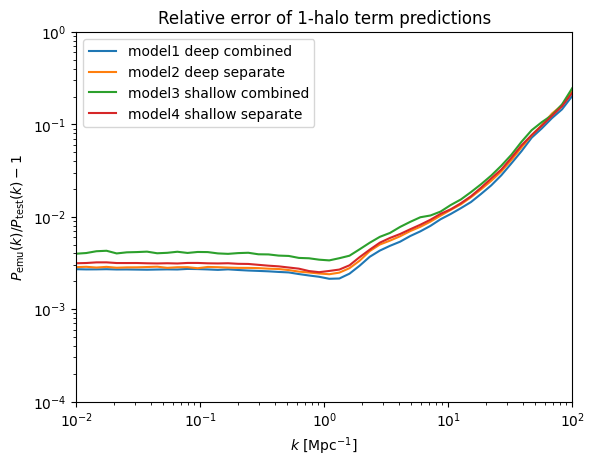

In [39]:
# do plot
fig, ax=plt.subplots()
ax.plot(ks, percentiles_1h_test1[2, :], color='C0', label=r'model1 deep combined')

ax.plot(ks, percentiles_1h_test2[2, :], color='C1', label=r'model2 deep separate')

ax.plot(ks, percentiles_1h_test3[2, :], color='C2', label=r'model3 shallow combined')

ax.plot(ks, percentiles_1h_test4[2, :], color='C3', label=r'model4 shallow separate')




ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlim(1e-2, 100)
ax.set_ylim(1e-4, 1)

ax.set_ylabel(r'$P_\mathrm{emu}(k)/P_\mathrm{test}(k)-1$')
ax.set_xlabel(r'$k$ [Mpc$^{-1}$]')
ax.set_title('Relative error of 1-halo term predictions')

#plt.savefig(f'../Plots/Relativ_error{timestamp}.pdf')

plt.legend()

plt.savefig(f'../Plots/FinalExamples/1haloComparison.png', dpi=600)


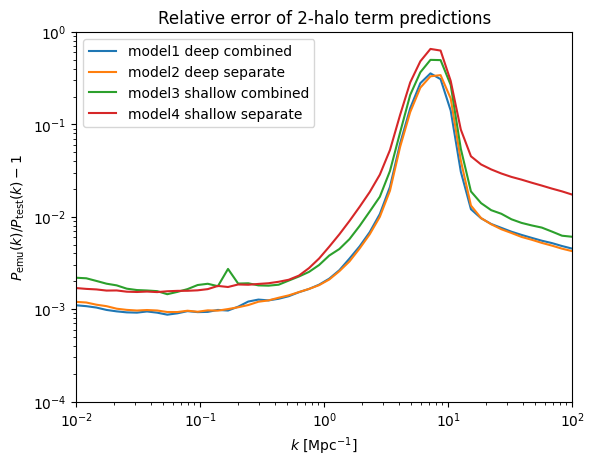

In [40]:
# do plot
fig, ax=plt.subplots()
ax.plot(ks, percentiles_2h_test1[2, :], color='C0', label=r'model1 deep combined')

ax.plot(ks, percentiles_2h_test2[2, :], color='C1', label=r'model2 deep separate')

ax.plot(ks, percentiles_2h_test3[2, :], color='C2', label=r'model3 shallow combined')

ax.plot(ks, percentiles_2h_test4[2, :], color='C3', label=r'model4 shallow separate')




ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlim(1e-2, 100)
ax.set_ylim(1e-4, 1)

ax.set_ylabel(r'$P_\mathrm{emu}(k)/P_\mathrm{test}(k)-1$')
ax.set_xlabel(r'$k$ [Mpc$^{-1}$]')
ax.set_title('Relative error of 2-halo term predictions')

#plt.savefig(f'../Plots/Relativ_error{timestamp}.pdf')

plt.legend()

plt.savefig(f'../Plots/FinalExamples/2haloComparison.png', dpi=600)

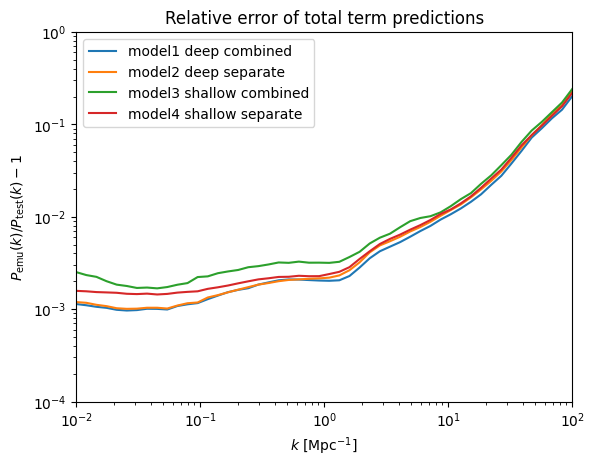

In [41]:
# do plot
fig, ax=plt.subplots()
ax.plot(ks, percentiles_total_test1[2, :], color='C0', label=r'model1 deep combined')

ax.plot(ks, percentiles_total_test2[2, :], color='C1', label=r'model2 deep separate')

ax.plot(ks, percentiles_total_test3[2, :], color='C2', label=r'model3 shallow combined')

ax.plot(ks, percentiles_total_test4[2, :], color='C3', label=r'model4 shallow separate')




ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlim(1e-2, 100)
ax.set_ylim(1e-4, 1)

ax.set_ylabel(r'$P_\mathrm{emu}(k)/P_\mathrm{test}(k)-1$')
ax.set_xlabel(r'$k$ [Mpc$^{-1}$]')
ax.set_title('Relative error of total term predictions')

#plt.savefig(f'../Plots/Relativ_error{timestamp}.pdf')

plt.legend()

plt.savefig(f'../Plots/FinalExamples/totalhaloComparison.png', dpi=600)

In [42]:
def count_params(model):
    return model.count_params()

params_model1 = count_params(model1)
params_model2 = count_params(model2_1halo) + count_params(model2_2halo)
params_model3 = count_params(model3)
params_model4 = count_params(model4_1halo) + count_params(model4_2halo)

print(f"Model 1: {params_model1:,} trainierbare Weights")
print(f"Model 2: {params_model2:,} trainierbare Weights (1-halo + 2-halo)")
print(f"Model 3: {params_model3:,} trainierbare Weights")
print(f"Model 4: {params_model4:,} trainierbare Weights (1-halo + 2-halo)")

Model 1: 10,405,734 trainierbare Weights
Model 2: 1,925,469 trainierbare Weights (1-halo + 2-halo)
Model 3: 535,032 trainierbare Weights
Model 4: 848,503 trainierbare Weights (1-halo + 2-halo)


In [44]:
log_indices = [7, 8]  # Die Indizes, die zuvor log-transformiert wurden

# Rücktransformation per 10er-Potenz
training_features[:, log_indices] = 10 ** training_features[:, log_indices]
validation_features[:, log_indices] = 10 ** validation_features[:, log_indices]
testing_features[:, log_indices] = 10 ** testing_features[:, log_indices]

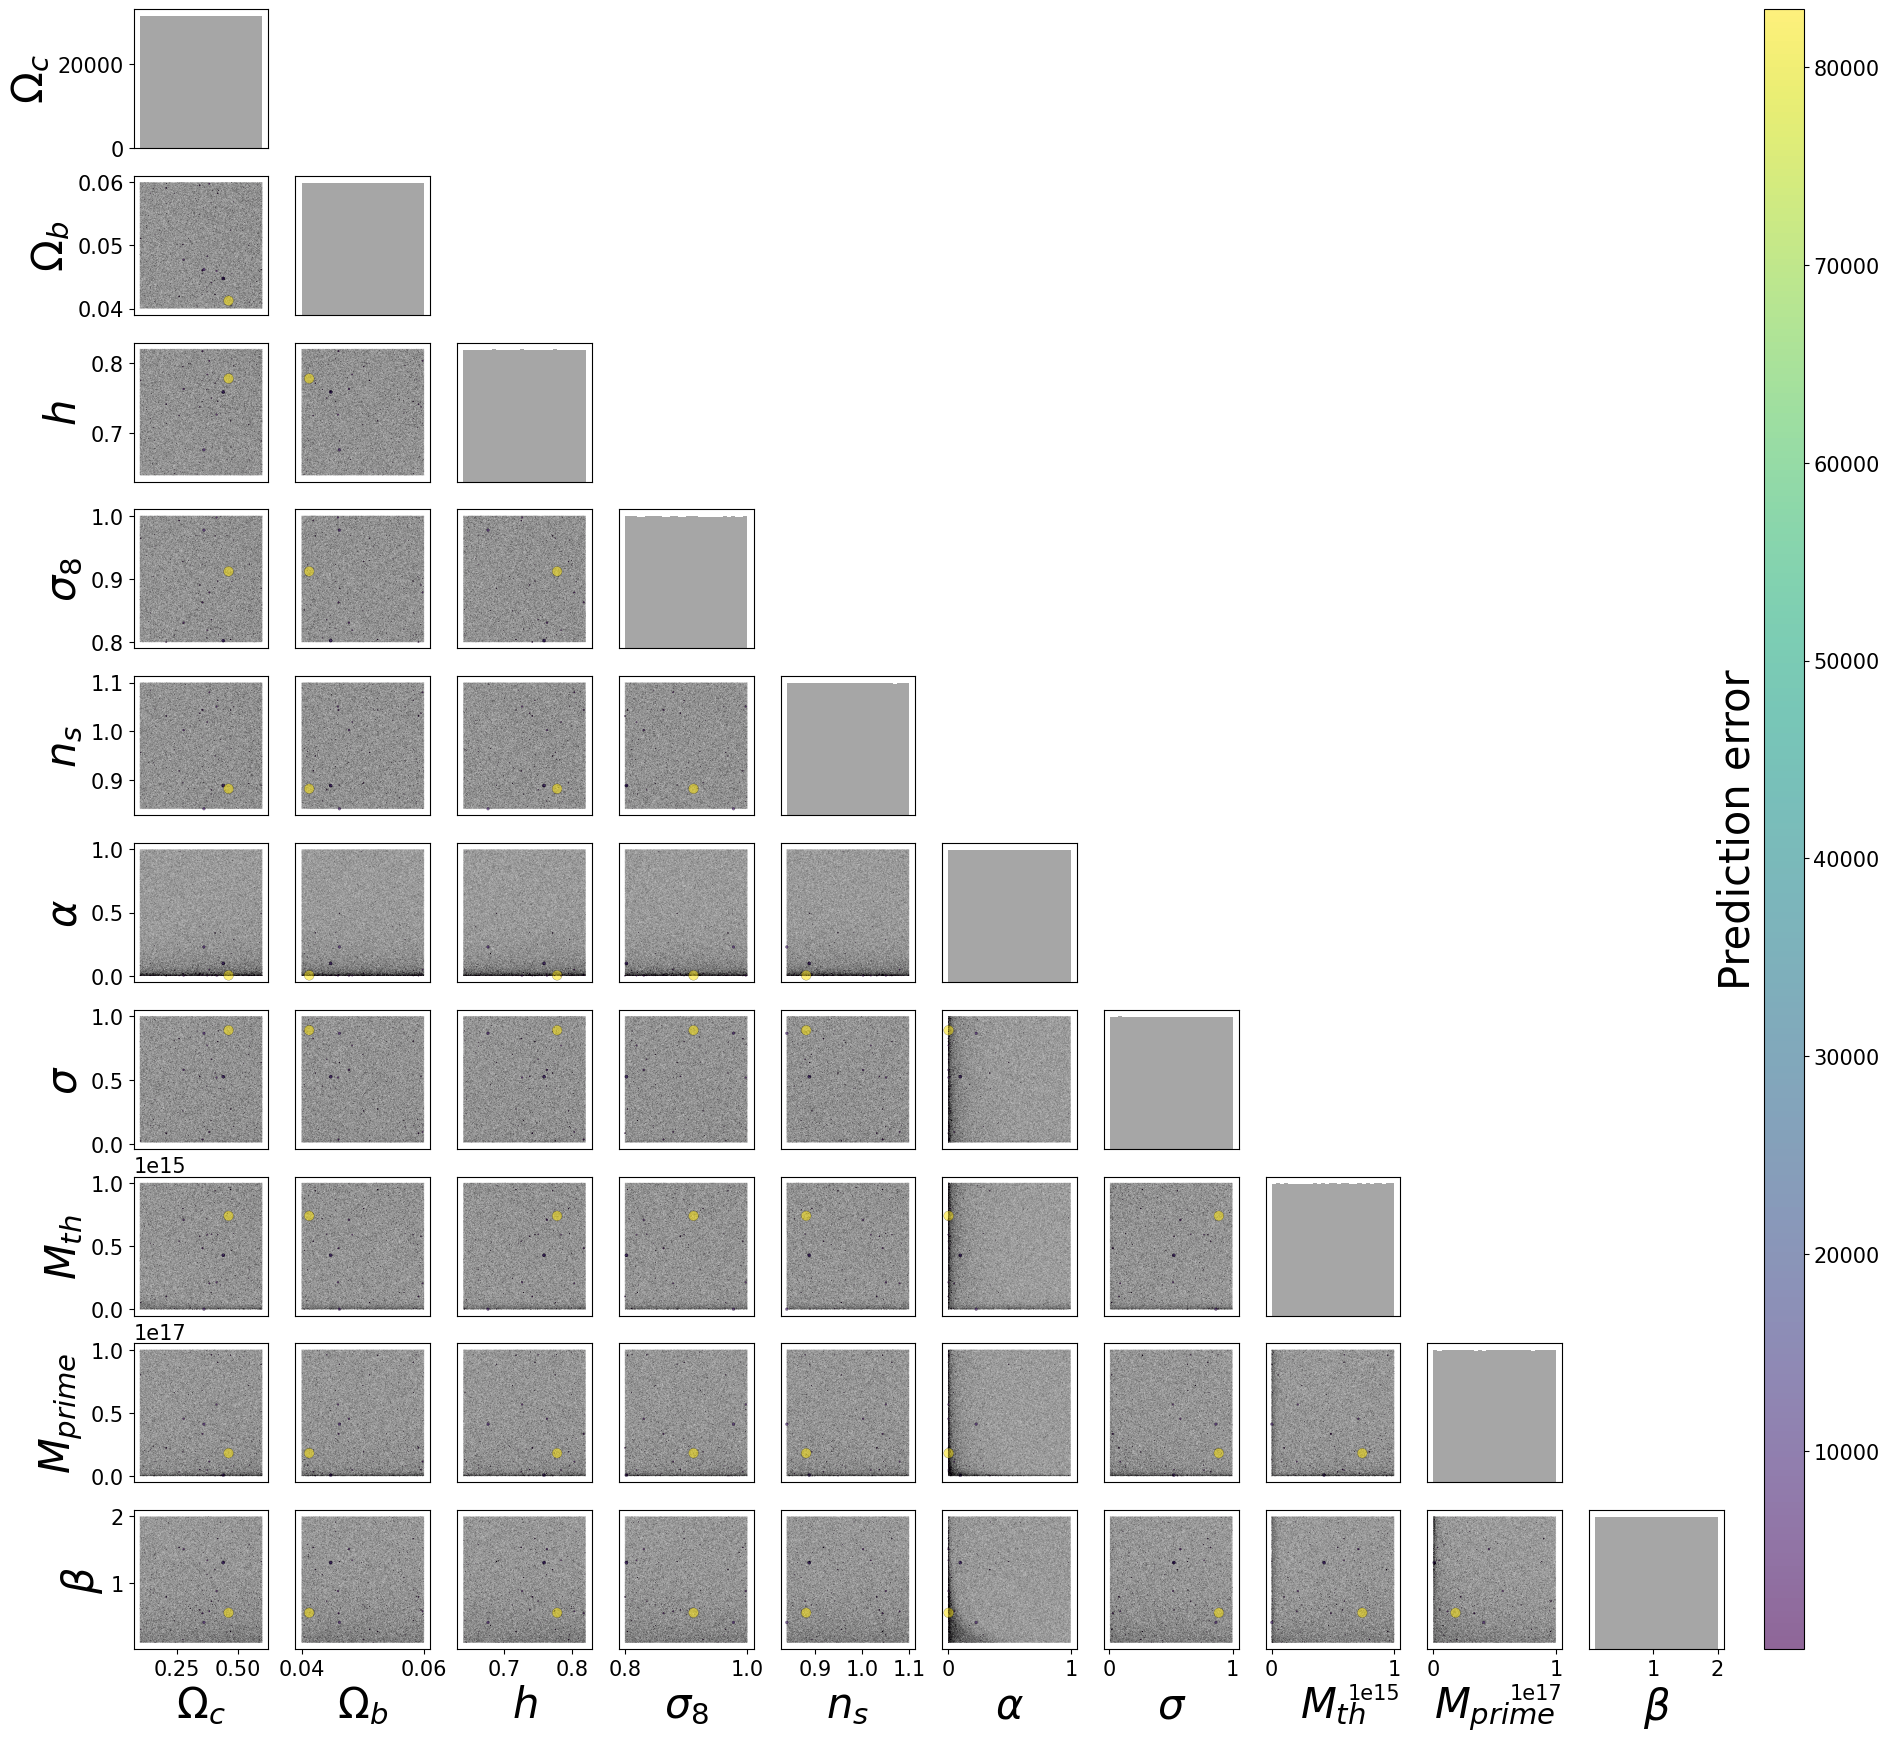

In [ ]:
import matplotlib.colors as mcolors
import numpy as np
import matplotlib.pyplot as plt

# Beispielhafte Dimensionen
N_params = testing_features.shape[1]
param_names = [r'$\Omega_c$', r'$\Omega_b$', r'$h$', r'$\sigma_8$', r'$n_s$', 
               r'$\alpha$', r'$\sigma$', r'$M_{th}$', r'$M_{prime}$', r'$\beta$']

# 95%-Quantil für Fehler als Maximum für Skalierung
max_error = np.percentile(test_max_error_per_sample_1, 95)
scaled_sizes = 50 * np.clip(test_max_error_per_sample_1, 0, max_error) / max_error

# Subplots nur untere Dreiecksmatrix + Diagonale
fig, axes = plt.subplots(N_params, N_params, figsize=(20, 20))

for i in range(N_params):
    for j in range(N_params):
        ax = axes[i, j]
        
        if i < j:
            ax.set_visible(False)
            continue
        
        elif i == j:
            ax.hist(testing_features[:, i], bins=30, color="gray", alpha=0.7)
        
        else:
            sc = ax.scatter(testing_features[:, j],
                            testing_features[:, i],
                            s=scaled_sizes,
                            c=test_max_error_per_sample_1,
                            norm=mcolors.LogNorm(vmin=np.percentile(test_max_error_per_sample_1, 0),
                                                 vmax=max_error),
                            cmap="viridis",
                            alpha=0.6,
                            edgecolor="none")
        
        if i == N_params - 1:
            ax.set_xlabel(param_names[j], fontsize=30)
        else:
            ax.set_xticks([])
        
        if j == 0:
            ax.set_ylabel(param_names[i], fontsize=30)
        else:
            ax.set_yticks([])

        ax.tick_params(axis='both', which='both', labelsize=15)
        if ax.xaxis.get_offset_text() is not None:
            ax.xaxis.get_offset_text().set_fontsize(15)
        if ax.yaxis.get_offset_text() is not None:
            ax.yaxis.get_offset_text().set_fontsize(15)

for row in axes:
    for ax in row:
        if hasattr(ax, 'xaxis'):
            ax.xaxis.get_offset_text().set_fontsize(15)
        if hasattr(ax, 'yaxis'):
            ax.yaxis.get_offset_text().set_fontsize(15)

# Layout & Farbskala
fig.subplots_adjust(right=0.92, top=0.93)
cbar_ax = fig.add_axes([0.94, 0.11, 0.02, 0.82])
cbar = plt.colorbar(sc, cax=cbar_ax, label="Error")
cbar.ax.tick_params(labelsize=15)
cbar.ax.yaxis.set_label_position('left')
cbar.set_label("Prediction error", fontsize=30)

plt.title("Parameterspace with prediction error of each sample - Model 1")

#plt.savefig(f'../Plots/Examples/ParameterspaceTest.png', dpi=500)

plt.show()


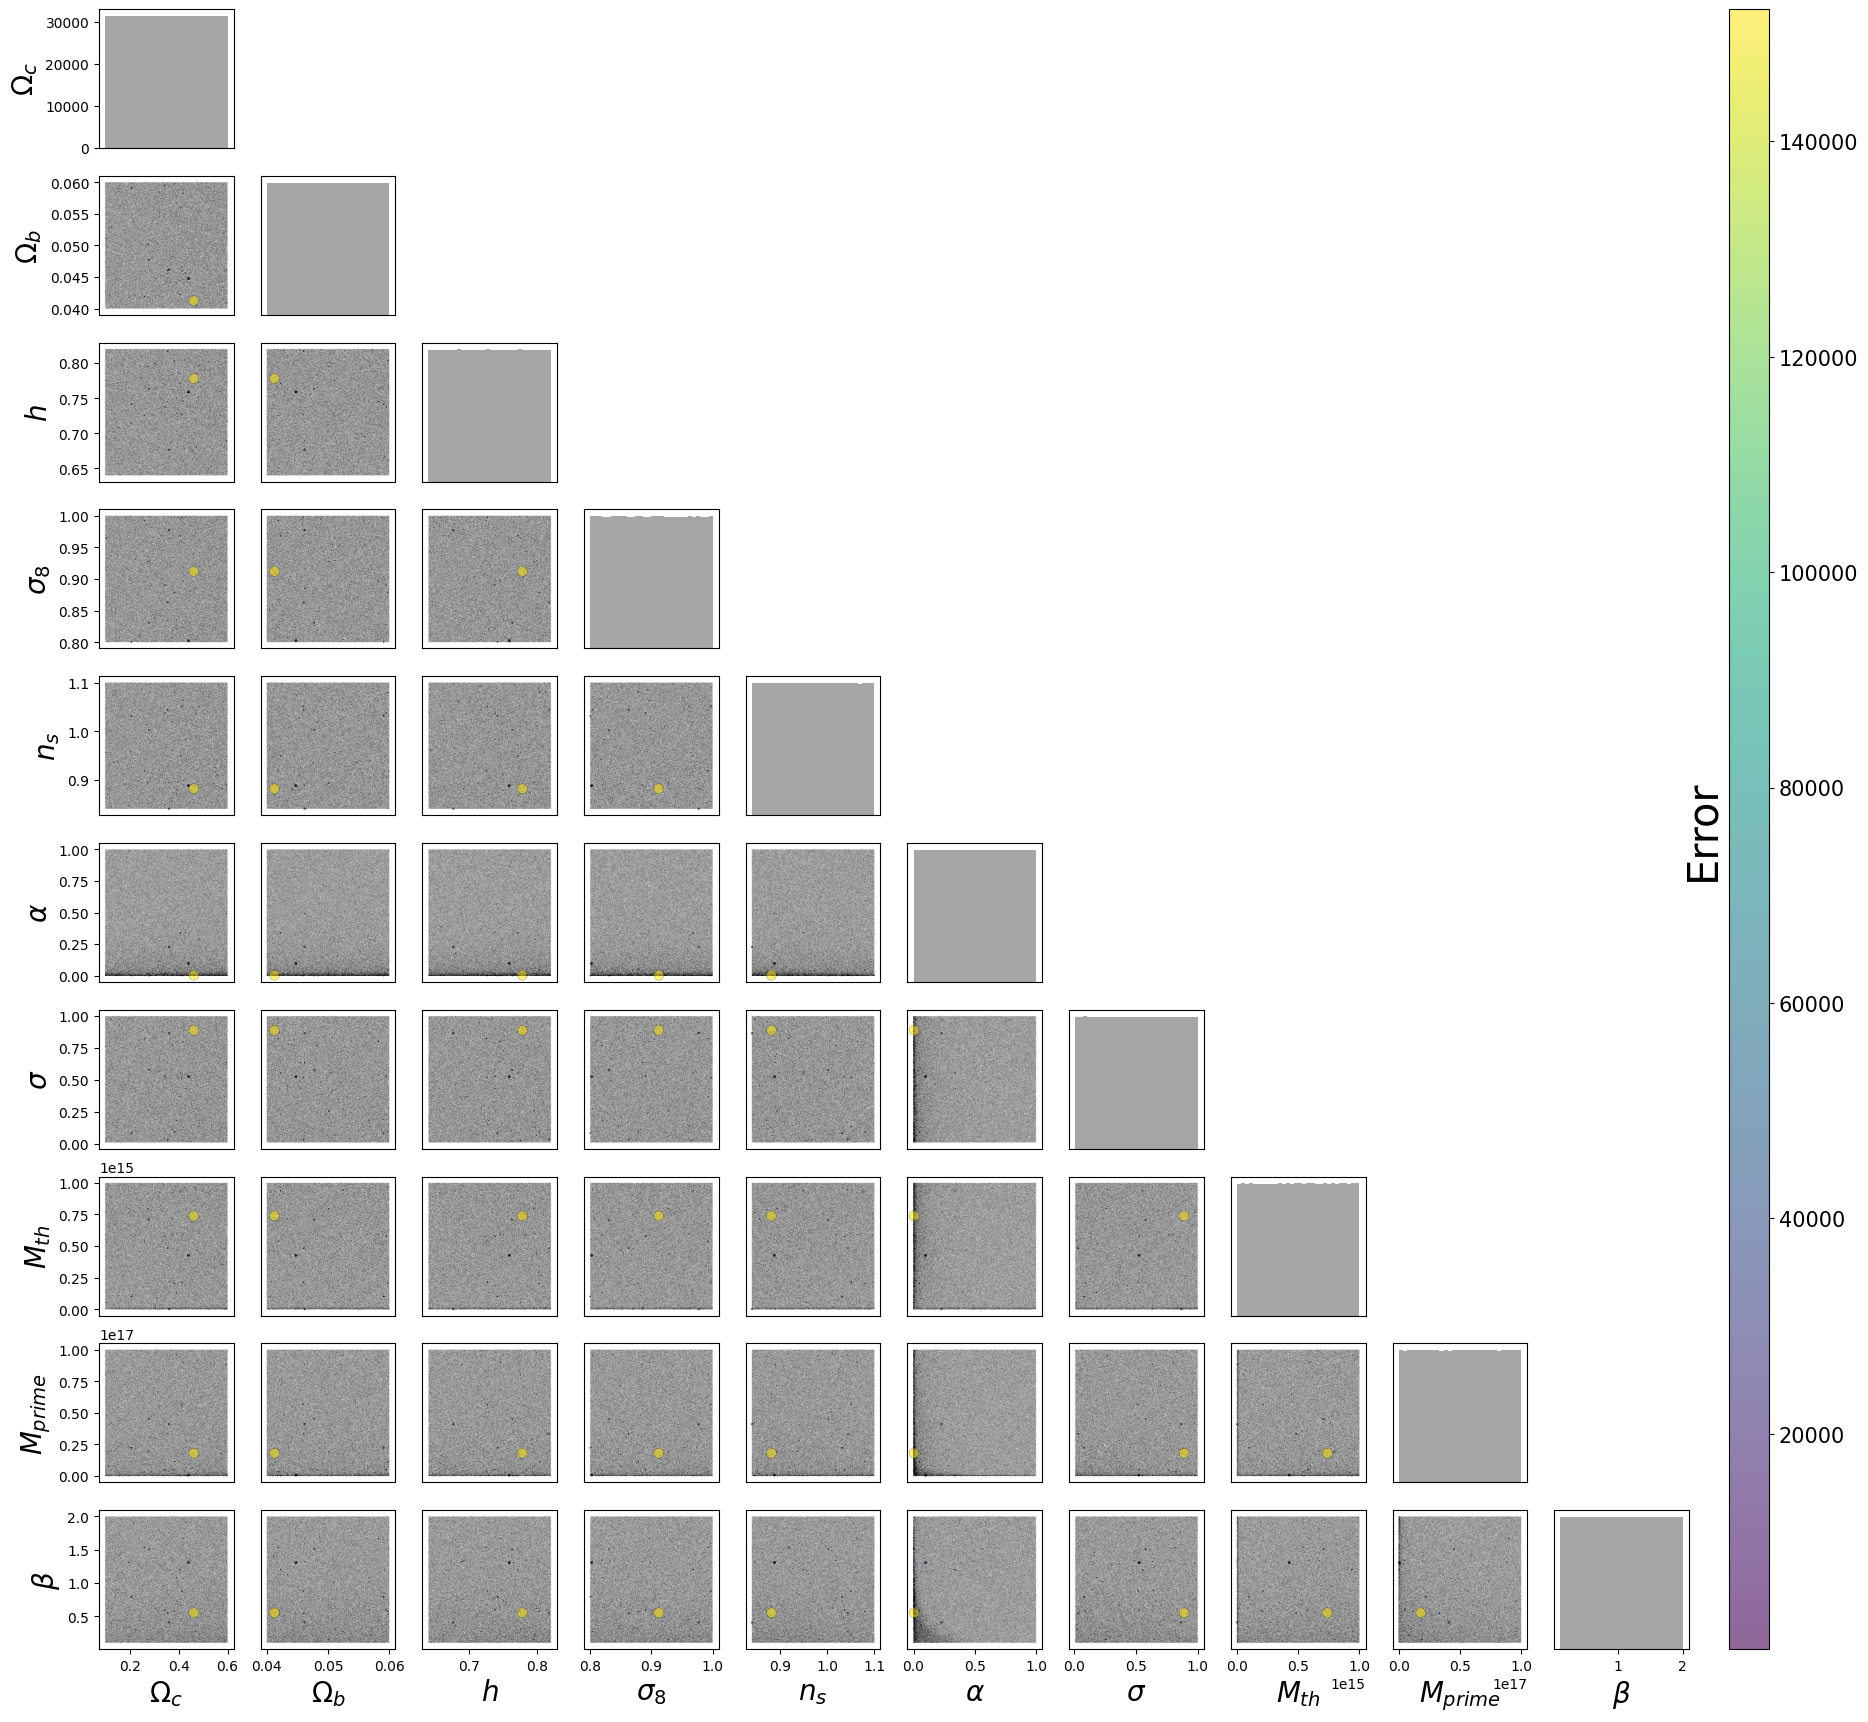

In [ ]:
import matplotlib.colors as mcolors
import numpy as np
import matplotlib.pyplot as plt

# Beispielhafte Dimensionen
N_params = testing_features.shape[1]
param_names = [r'$\Omega_c$', r'$\Omega_b$', r'$h$', r'$\sigma_8$', r'$n_s$', 
               r'$\alpha$', r'$\sigma$', r'$M_{th}$', r'$M_{prime}$', r'$\beta$']

# 95%-Quantil für Fehler als Maximum für Skalierung
max_error = np.percentile(test_max_error_per_sample_2, 95)
scaled_sizes = 50 * np.clip(test_max_error_per_sample_2, 0, max_error) / max_error

# Subplots nur untere Dreiecksmatrix + Diagonale
fig, axes = plt.subplots(N_params, N_params, figsize=(20, 20))

for i in range(N_params):
    for j in range(N_params):
        ax = axes[i, j]
        
        if i < j:
            ax.set_visible(False)
            continue
        
        elif i == j:
            ax.hist(testing_features[:, i], bins=30, color="gray", alpha=0.7)
        
        else:
            sc = ax.scatter(testing_features[:, j],
                            testing_features[:, i],
                            s=scaled_sizes,
                            c=test_max_error_per_sample_2,
                            norm=mcolors.LogNorm(vmin=np.percentile(test_max_error_per_sample_2, 0),
                                                 vmax=max_error),
                            cmap="viridis",
                            alpha=0.6,
                            edgecolor="none")
        
        if i == N_params - 1:
            ax.set_xlabel(param_names[j], fontsize=30)
        else:
            ax.set_xticks([])
        
        if j == 0:
            ax.set_ylabel(param_names[i], fontsize=30)
        else:
            ax.set_yticks([])

        ax.tick_params(axis='both', which='both', labelsize=15)
        if ax.xaxis.get_offset_text() is not None:
            ax.xaxis.get_offset_text().set_fontsize(15)
        if ax.yaxis.get_offset_text() is not None:
            ax.yaxis.get_offset_text().set_fontsize(15)

for row in axes:
    for ax in row:
        if hasattr(ax, 'xaxis'):
            ax.xaxis.get_offset_text().set_fontsize(15)
        if hasattr(ax, 'yaxis'):
            ax.yaxis.get_offset_text().set_fontsize(15)

# Layout & Farbskala
fig.subplots_adjust(right=0.92, top=0.93)
cbar_ax = fig.add_axes([0.94, 0.11, 0.02, 0.82])
cbar = plt.colorbar(sc, cax=cbar_ax, label="Error")
cbar.ax.tick_params(labelsize=15)
cbar.ax.yaxis.set_label_position('left')
cbar.set_label("Prediction error", fontsize=30)

plt.title("Parameterspace with prediction error of each sample - Model 2")

#plt.savefig(f'../Plots/Examples/ParameterspaceTest.png', dpi=500)

plt.show()


In [ ]:
import matplotlib.colors as mcolors
import numpy as np
import matplotlib.pyplot as plt

# Beispielhafte Dimensionen
N_params = testing_features.shape[1]
param_names = [r'$\Omega_c$', r'$\Omega_b$', r'$h$', r'$\sigma_8$', r'$n_s$', 
               r'$\alpha$', r'$\sigma$', r'$M_{th}$', r'$M_{prime}$', r'$\beta$']

# 95%-Quantil für Fehler als Maximum für Skalierung
max_error = np.percentile(test_max_error_per_sample_3, 95)
scaled_sizes = 50 * np.clip(test_max_error_per_sample_3, 0, max_error) / max_error

# Subplots nur untere Dreiecksmatrix + Diagonale
fig, axes = plt.subplots(N_params, N_params, figsize=(20, 20))

for i in range(N_params):
    for j in range(N_params):
        ax = axes[i, j]
        
        if i < j:
            ax.set_visible(False)
            continue
        
        elif i == j:
            ax.hist(testing_features[:, i], bins=30, color="gray", alpha=0.7)
        
        else:
            sc = ax.scatter(testing_features[:, j],
                            testing_features[:, i],
                            s=scaled_sizes,
                            c=test_max_error_per_sample_3,
                            norm=mcolors.LogNorm(vmin=np.percentile(test_max_error_per_sample_3, 0),
                                                 vmax=max_error),
                            cmap="viridis",
                            alpha=0.6,
                            edgecolor="none")
        
        if i == N_params - 1:
            ax.set_xlabel(param_names[j], fontsize=30)
        else:
            ax.set_xticks([])
        
        if j == 0:
            ax.set_ylabel(param_names[i], fontsize=30)
        else:
            ax.set_yticks([])

        ax.tick_params(axis='both', which='both', labelsize=15)
        if ax.xaxis.get_offset_text() is not None:
            ax.xaxis.get_offset_text().set_fontsize(15)
        if ax.yaxis.get_offset_text() is not None:
            ax.yaxis.get_offset_text().set_fontsize(15)

for row in axes:
    for ax in row:
        if hasattr(ax, 'xaxis'):
            ax.xaxis.get_offset_text().set_fontsize(15)
        if hasattr(ax, 'yaxis'):
            ax.yaxis.get_offset_text().set_fontsize(15)

# Layout & Farbskala
fig.subplots_adjust(right=0.92, top=0.93)
cbar_ax = fig.add_axes([0.94, 0.11, 0.02, 0.82])
cbar = plt.colorbar(sc, cax=cbar_ax, label="Error")
cbar.ax.tick_params(labelsize=15)
cbar.ax.yaxis.set_label_position('left')
cbar.set_label("Prediction error", fontsize=30)

plt.title("Parameterspace with prediction error of each sample - Model 1")

#plt.savefig(f'../Plots/Examples/ParameterspaceTest.png', dpi=500)

plt.show()


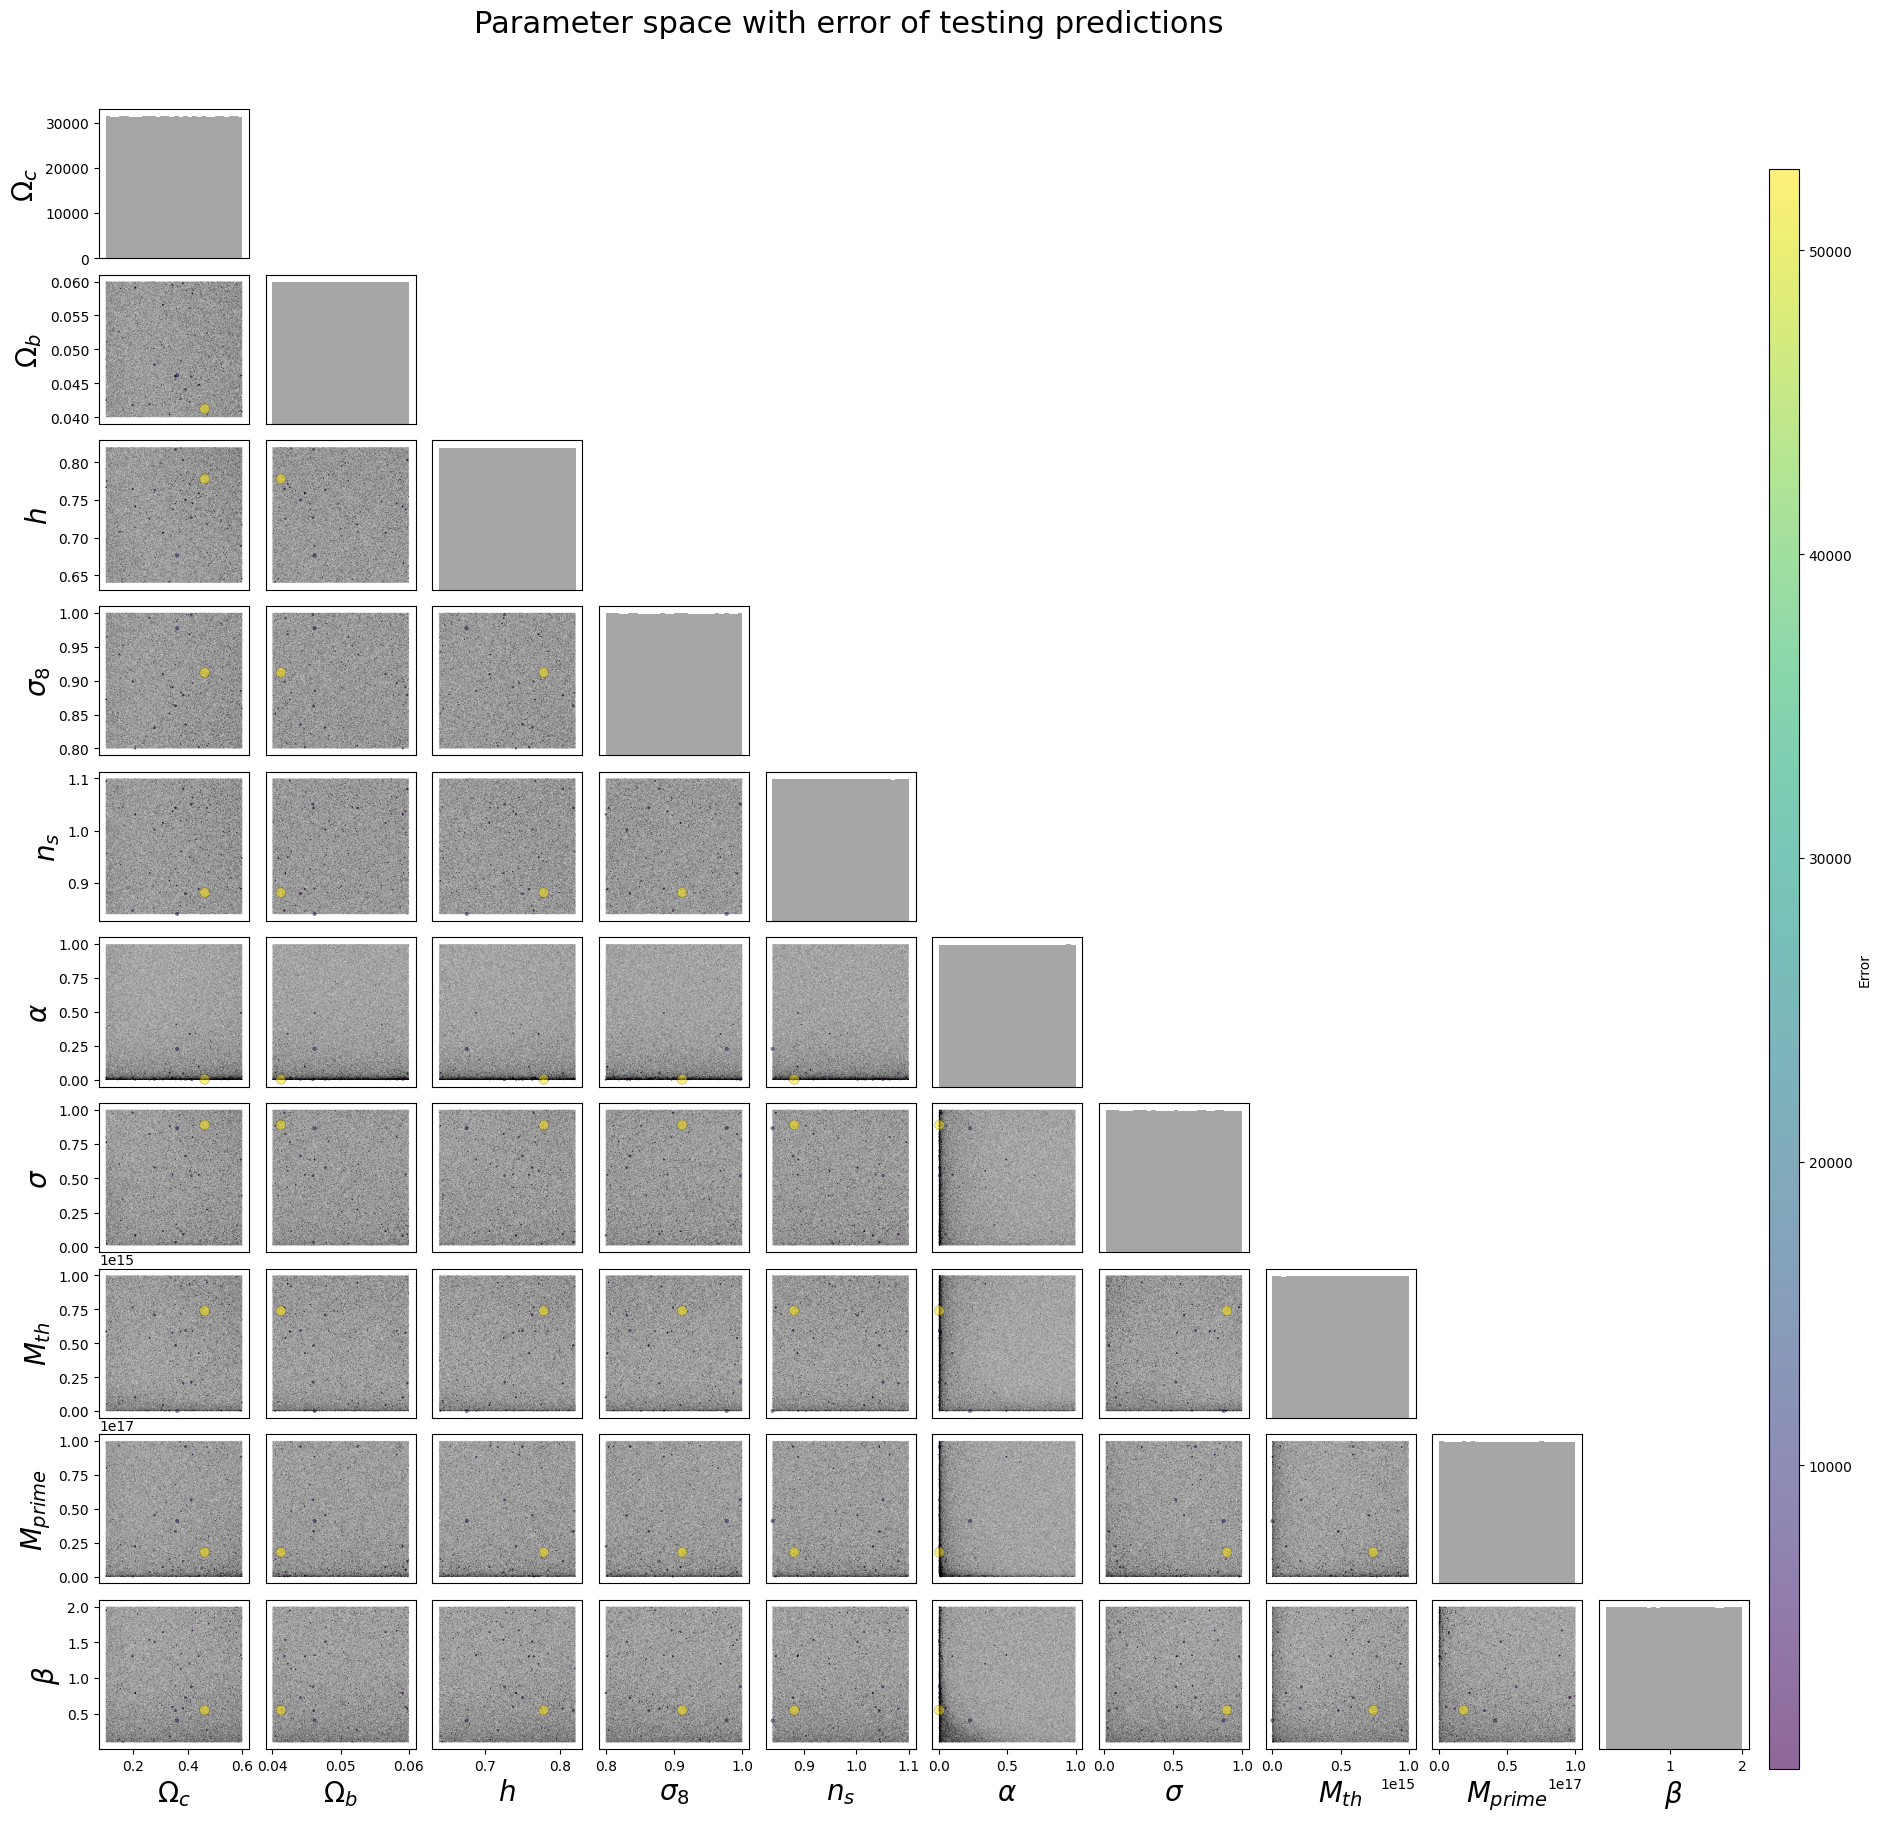

In [ ]:
import matplotlib.colors as mcolors
import numpy as np
import matplotlib.pyplot as plt

# Beispielhafte Dimensionen
N_params = testing_features.shape[1]
param_names = [r'$\Omega_c$', r'$\Omega_b$', r'$h$', r'$\sigma_8$', r'$n_s$', 
               r'$\alpha$', r'$\sigma$', r'$M_{th}$', r'$M_{prime}$', r'$\beta$']

# 95%-Quantil für Fehler als Maximum für Skalierung
max_error = np.percentile(test_max_error_per_sample_4, 95)
scaled_sizes = 50 * np.clip(test_max_error_per_sample_4, 0, max_error) / max_error

# Subplots nur untere Dreiecksmatrix + Diagonale
fig, axes = plt.subplots(N_params, N_params, figsize=(20, 20))

for i in range(N_params):
    for j in range(N_params):
        ax = axes[i, j]
        
        if i < j:
            ax.set_visible(False)
            continue
        
        elif i == j:
            ax.hist(testing_features[:, i], bins=30, color="gray", alpha=0.7)
        
        else:
            sc = ax.scatter(testing_features[:, j],
                            testing_features[:, i],
                            s=scaled_sizes,
                            c=test_max_error_per_sample_4,
                            norm=mcolors.LogNorm(vmin=np.percentile(test_max_error_per_sample_4, 0),
                                                 vmax=max_error),
                            cmap="viridis",
                            alpha=0.6,
                            edgecolor="none")
        
        if i == N_params - 1:
            ax.set_xlabel(param_names[j], fontsize=30)
        else:
            ax.set_xticks([])
        
        if j == 0:
            ax.set_ylabel(param_names[i], fontsize=30)
        else:
            ax.set_yticks([])

        ax.tick_params(axis='both', which='both', labelsize=15)
        if ax.xaxis.get_offset_text() is not None:
            ax.xaxis.get_offset_text().set_fontsize(15)
        if ax.yaxis.get_offset_text() is not None:
            ax.yaxis.get_offset_text().set_fontsize(15)

for row in axes:
    for ax in row:
        if hasattr(ax, 'xaxis'):
            ax.xaxis.get_offset_text().set_fontsize(15)
        if hasattr(ax, 'yaxis'):
            ax.yaxis.get_offset_text().set_fontsize(15)

# Layout & Farbskala
fig.subplots_adjust(right=0.92, top=0.93)
cbar_ax = fig.add_axes([0.94, 0.11, 0.02, 0.82])
cbar = plt.colorbar(sc, cax=cbar_ax, label="Error")
cbar.ax.tick_params(labelsize=15)
cbar.ax.yaxis.set_label_position('left')
cbar.set_label("Prediction error", fontsize=30)

plt.title("Parameterspace with prediction error of each sample - Model 1")

#plt.savefig(f'../Plots/Examples/ParameterspaceTest.png', dpi=500)

plt.show()
